# IS 455 — Chapter 17 Assignment: Fraud Detection Pipeline
## CRISP-DM Notebook: Predicting `is_fraud` in `shop.db`

**Author:** Calvin Bateman  
**Course:** IS 455 — Machine Learning in Python  
**Textbook:** *Machine Learning in Python: From Data Collection to Model Deployment* — Mark Keith, PhD  

---

This notebook demonstrates the complete **CRISP-DM process** for building and deploying a fraud-detection ML pipeline on the `shop.db` operational database. All code patterns follow the textbook (Chapters 2–4, 6–8, 13–16, 17).

### Database Schema (`shop.db`)
| Table | Rows | Key Columns |
|-------|------|-------------|
| `orders` | 5,000 | `order_id`, `order_datetime`, `payment_method`, `device_type`, `ip_country`, `order_total`, `is_fraud` |
| `customers` | 250 | `customer_id`, `full_name`, `gender`, `birthdate`, `customer_segment`, `loyalty_tier` |
| `order_items` | 15,022 | `order_id`, `product_id`, `quantity`, `unit_price`, `line_total` |
| `products` | 100 | `product_id`, `category`, `price`, `cost` |
| `shipments` | 5,000 | `order_id`, `carrier`, `shipping_method`, `distance_band`, `promised_days`, `actual_days` |

### Notebook Phases
| Phase | CRISP-DM Stage | Textbook Reference |
|-------|---------------|-------------------|
| 0 | Setup & Data Loading | Ch. 2 |
| 1 | Business Understanding | Ch. 1 |
| 2 | Data Understanding | Ch. 6, 8 |
| 3 | Data Preparation | Ch. 7, 17.4 |
| 4 | Modeling | Ch. 13, 14, 17.5 |
| 5 | Evaluation & Tuning | Ch. 15, 16 |
| 6 | Deployment | Ch. 17.5–17.7 |

---
## Phase 0: Setup & Data Loading

In [47]:
!pip install supabase -q
from supabase import create_client

SUPABASE_URL = "https://xxxx.supabase.co"
SUPABASE_KEY = "your-service-role-key"
sb = create_client(SUPABASE_URL, SUPABASE_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.2 MB/s eta 0:00:00


In [48]:
# 0.1 — Imports
import sqlite3, json, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import pandas.api.types as ptypes
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, kendalltau, spearmanr, f_oneway, chi2_contingency
from scipy.stats import yeojohnson

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, learning_curve, GridSearchCV)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, log_loss,
                              classification_report, confusion_matrix,
                              precision_score, recall_score,
                              RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.feature_selection import (VarianceThreshold, SelectKBest,
                                        f_classif, RFECV)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (10, 4)
print("✓ All imports successful")

✓ All imports successful


### 0.2 — Connect to `shop.db` and Inspect Tables

We connect directly to the operational database and list all available tables following the **Chapter 17.4** ETL pattern.

In [49]:
# 0.2 — Connect to shop.db and verify all tables are present
DB_PATH = Path("/content/drive/MyDrive/School/Junior Core/455/17.1/shop.db")
assert DB_PATH.exists(), "⚠️  shop.db not found — place it in the same folder as this notebook."

with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
    )
print("Tables in shop.db:")
print(tables.to_string(index=False))

Tables in shop.db:
           name
      customers
    order_items
         orders
product_reviews
       products
      shipments
sqlite_sequence


In [50]:
# 0.3 — Load all tables into DataFrames
with sqlite3.connect(DB_PATH) as conn:
    orders      = pd.read_sql("SELECT * FROM orders",      conn)
    customers   = pd.read_sql("SELECT * FROM customers",   conn)
    order_items = pd.read_sql("SELECT * FROM order_items", conn)
    products    = pd.read_sql("SELECT * FROM products",    conn)
    shipments   = pd.read_sql("SELECT * FROM shipments",   conn)

print(f"orders:      {orders.shape[0]:,} rows × {orders.shape[1]} cols")
print(f"customers:   {customers.shape[0]:,} rows × {customers.shape[1]} cols")
print(f"order_items: {order_items.shape[0]:,} rows × {order_items.shape[1]} cols")
print(f"products:    {products.shape[0]:,} rows × {products.shape[1]} cols")
print(f"shipments:   {shipments.shape[0]:,} rows × {shipments.shape[1]} cols")

orders:      5,000 rows × 17 cols
customers:   250 rows × 12 cols
order_items: 15,022 rows × 6 cols
products:    100 rows × 7 cols
shipments:   5,000 rows × 9 cols


In [51]:
# 0.4 — Schema peek: dtypes + head(3) for each table
for name, df in [("orders", orders), ("customers", customers),
                  ("order_items", order_items), ("products", products),
                  ("shipments", shipments)]:
    print(f"\n{'═'*55}  {name}  {'═'*55}")
    print(df.dtypes.to_string())
    print()
    display(df.head(3))


═══════════════════════════════════════════════════════  orders  ═══════════════════════════════════════════════════════
order_id            int64
customer_id         int64
order_datetime     object
billing_zip        object
shipping_zip       object
shipping_state     object
payment_method     object
device_type        object
ip_country         object
promo_used          int64
promo_code         object
order_subtotal    float64
shipping_fee      float64
tax_amount        float64
order_total       float64
risk_score        float64
is_fraud            int64



,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.9500,15.4400,46.3000,724.6900,38.3000,0
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.9200,14.7400,66.6100,944.2700,94.9000,0
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.0900,14.0400,40.7200,850.8500,53.8000,1



═══════════════════════════════════════════════════════  customers  ═══════════════════════════════════════════════════════
customer_id          int64
full_name           object
email               object
gender              object
birthdate           object
created_at          object
city                object
state               object
zip_code            object
customer_segment    object
loyalty_tier        object
is_active            int64



,customer_id,full_name,email,gender,birthdate,created_at,city,state,zip_code,customer_segment,loyalty_tier,is_active
0,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1
1,2,Juan Flores,juanflores1@example.com,Male,1995-05-29,2025-10-11 16:37:40,Hudson,CO,88907,budget,none,1
2,3,Mary González,marygonzález2@example.com,Female,2005-06-30,2025-06-26 16:37:40,Oxford,OH,46421,budget,gold,1



═══════════════════════════════════════════════════════  order_items  ═══════════════════════════════════════════════════════
order_item_id      int64
order_id           int64
product_id         int64
quantity           int64
unit_price       float64
line_total       float64



,order_item_id,order_id,product_id,quantity,unit_price,line_total
0,1,1,15,1,28.1000,28.1000
1,2,1,58,2,23.1600,46.3200
2,3,1,73,2,99.9000,199.8000



═══════════════════════════════════════════════════════  products  ═══════════════════════════════════════════════════════
product_id        int64
sku              object
product_name     object
category         object
price           float64
cost            float64
is_active         int64



,product_id,sku,product_name,category,price,cost,is_active
0,1,SKU-0001,Portable Tool Kit,Garden,49.0100,24.8100,1
1,2,SKU-0002,Premium Monitor,Automotive,286.2700,170.4400,1
2,3,SKU-0003,Lightweight Flashlight,Books,31.1200,17.8200,1



═══════════════════════════════════════════════════════  shipments  ═══════════════════════════════════════════════════════
shipment_id         int64
order_id            int64
ship_datetime      object
carrier            object
shipping_method    object
distance_band      object
promised_days       int64
actual_days         int64
late_delivery       int64



,shipment_id,order_id,ship_datetime,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery
0,1,1,2025-11-29 09:51:07,UPS,expedited,regional,3,5,1
1,2,2,2025-09-02 08:25:59,FedEx,expedited,local,2,3,1
2,3,3,2025-12-16 13:24:41,FedEx,expedited,national,4,8,1


is_fraud value counts:
          count  proportion
is_fraud                   
0          4682      0.9364
1           318      0.0636


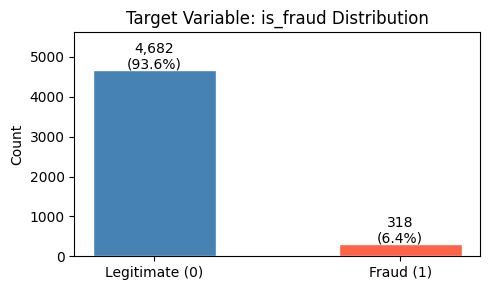

In [52]:
# 0.5 — Target variable: is_fraud class balance
print("is_fraud value counts:")
vc = orders["is_fraud"].value_counts()
vp = orders["is_fraud"].value_counts(normalize=True)
print(pd.concat([vc, vp.round(4)], axis=1, keys=["count","proportion"]))

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], vc.values,
               color=["steelblue", "tomato"], edgecolor="white", width=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{v:,}\n({v/len(orders)*100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Count"); ax.set_title("Target Variable: is_fraud Distribution")
ax.set_ylim(0, vc.max() * 1.2)
plt.tight_layout(); plt.show()

---
## Phase 1: Business Understanding

### 1.1 Problem Definition

Fraudulent orders represent a direct financial loss and reputational risk. Unlike late deliveries — which are operational inconveniences — fraud results in chargeback costs, inventory loss, and potential regulatory exposure.

**Business question:** Given everything known about an order *at the time it is placed*, how likely is it to be fraudulent?

### 1.2 Prediction Task

| Property | Value |
|----------|-------|
| **Type** | Binary classification |
| **Target** | `is_fraud` in the `orders` table |
| **Positive class (1)** | Fraudulent order (~6.4% of all orders) |
| **Negative class (0)** | Legitimate order (~93.6% of all orders) |
| **Prediction timing** | At order placement — before fulfillment or shipping |

### 1.3 How Predictions Will Be Used

The model outputs a **fraud probability** per order. These probabilities are written back to the operational database into an `order_predictions_fraud` table. The Next.js web application reads that table to:
1. **Flag high-probability orders** for manual review before fulfillment
2. **Sort a fraud review queue** by probability (highest risk first)
3. Surface a **"Run Scoring" button** that re-runs inference on demand

This is the deployment pattern from **Chapter 17**: *the application doesn't run ML code — it reads predictions like any other table.*

### 1.4 Success Criteria & Metric Justification

Because fraud represents only ~6.4% of orders, **accuracy is misleading** — a model predicting "never fraud" would score 93.6% accuracy but catch zero frauds.

| Metric | Why it matters for fraud |
|--------|--------------------------|
| **Recall (fraud class)** | Primary goal: catch as many real frauds as possible |
| **Precision (fraud class)** | Secondary: avoid overwhelming the review team with false alarms |
| **F1 Score** | Harmonic mean — balances recall and precision |
| **ROC AUC** | Overall ranking ability at all probability thresholds |
| **PR AUC** | More informative than ROC for imbalanced classes |
| **Log Loss** | Probability calibration quality (important for threshold tuning) |

**Target benchmark:** Recall ≥ 0.70 at Precision ≥ 0.50 on the fraud class.

---
## Phase 2: Data Understanding

We explore the data at the univariate (feature-by-feature) and bivariate (feature vs. `is_fraud`) levels using automated functions from **Chapter 6** and **Chapter 8**.

### 2.1 — ETL: Denormalize to One Row per Order (Chapter 17.4)

Before exploration we join the normalized tables into a single analytical DataFrame — one row per order. This is the **Chapter 17.4** ETL pattern: extract, join, and construct features before any modeling begins.

In [53]:
# 2.1a — Aggregate order_items to order-level features
order_agg = (
    order_items
    .groupby("order_id")
    .agg(
        num_items          =("quantity",    "sum"),
        num_unique_products=("product_id",  "nunique"),
        avg_unit_price     =("unit_price",  "mean"),
        max_unit_price     =("unit_price",  "max"),
    )
    .reset_index()
)
print(f"order_agg shape: {order_agg.shape}")
order_agg.head(3)

order_agg shape: (5000, 5)


,order_id,num_items,num_unique_products,avg_unit_price,max_unit_price
0,1,9,5,69.2420,99.9000
1,2,7,5,133.3000,241.5100
2,3,5,3,140.8500,230.5000


In [54]:
# 2.1b — Get the dominant product category per order
order_cats = (
    order_items
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("order_id")["category"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    .reset_index()
    .rename(columns={"category": "top_category"})
)
print(f"order_cats shape: {order_cats.shape}")
print("Category distribution across orders:")
print(order_cats["top_category"].value_counts())

order_cats shape: (5000, 2)
Category distribution across orders:
top_category
Apparel        1208
Automotive      805
Books           680
Beauty          541
Home            507
Electronics     358
Grocery         282
Sports          233
Toys            197
Garden          189
Name: count, dtype: int64


In [55]:
# 2.1c — Join all tables into one modeling DataFrame
# Shipments: use ONLY pre-delivery columns (carrier, method, distance, promised_days)
# actual_days and late_delivery are POST-delivery — using them would be data leakage.
ship_feats = shipments[["order_id", "carrier", "shipping_method",
                          "distance_band", "promised_days"]]

df = (
    orders
    .merge(
        customers[["customer_id", "full_name", "gender", "birthdate",
                   "customer_segment", "loyalty_tier"]],
        on="customer_id", how="left"
    )
    .merge(order_agg,  on="order_id", how="left")
    .merge(order_cats, on="order_id", how="left")
    .merge(ship_feats, on="order_id", how="left")
)

print(f"Modeling DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Modeling DataFrame: 5,000 rows × 31 columns

Columns: ['order_id', 'customer_id', 'order_datetime', 'billing_zip', 'shipping_zip', 'shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'promo_code', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'is_fraud', 'full_name', 'gender', 'birthdate', 'customer_segment', 'loyalty_tier', 'num_items', 'num_unique_products', 'avg_unit_price', 'max_unit_price', 'top_category', 'carrier', 'shipping_method', 'distance_band', 'promised_days']


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,full_name,gender,birthdate,customer_segment,loyalty_tier,num_items,num_unique_products,avg_unit_price,max_unit_price,top_category,carrier,shipping_method,distance_band,promised_days
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.9500,15.4400,46.3000,724.6900,38.3000,0,Patricia Diallo,Female,2005-06-08,standard,silver,9,5,69.2420,99.9000,Beauty,UPS,expedited,regional,3
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.9200,14.7400,66.6100,944.2700,94.9000,0,Patricia Diallo,Female,2005-06-08,standard,silver,7,5,133.3000,241.5100,Home,FedEx,expedited,local,2
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.0900,14.0400,40.7200,850.8500,53.8000,1,Patricia Diallo,Female,2005-06-08,standard,silver,5,3,140.8500,230.5000,Garden,FedEx,expedited,national,4


### 2.2 — Automated Univariate Statistics: `unistats()` (Chapter 6)

We build a reusable `unistats()` function following the **Chapter 6** pattern:
- Loop through columns and check `pd.api.types.is_numeric_dtype()` to branch behavior
- Initialize placeholder values at the **start of each loop iteration** to prevent carryover bugs
- Return a clean summary DataFrame

In [56]:
# 2.2 — unistats() function — Chapter 6 pattern
def unistats(df, features=None):
    """
    Automated univariate statistics for all columns in df.
    Numeric: count, missing_pct, unique, min, Q1, mean, median, mode, Q3, max, std, skew, kurtosis
    Categorical: count, missing_pct, unique, mode, mode_freq
    (Chapter 6 — is_numeric_dtype branching with placeholder initialization per iteration)
    """
    if features is None:
        features = df.columns.tolist()
    rows = []

    for feat in features:
        if feat not in df.columns:
            continue
        s = df[feat]

        # ─── Initialize placeholders at start of EACH iteration (Ch. 6 bug-prevention pattern)
        mn = mx = mean = median = std = skew = kurt = q1 = q3 = mode_freq = None
        mode_val = None
        dtype_label = "categorical"

        count       = int(s.count())
        missing     = int(s.isna().sum())
        missing_pct = round(missing / len(df), 4)
        unique      = int(s.nunique())

        if ptypes.is_numeric_dtype(s):
            dtype_label = "numeric"
            s_clean = s.dropna()
            if not s_clean.empty:
                mn     = round(float(s_clean.min()),         4)
                mx     = round(float(s_clean.max()),         4)
                mean   = round(float(s_clean.mean()),        4)
                median = round(float(s_clean.median()),      4)
                std    = round(float(s_clean.std()),         4)
                skew   = round(float(s_clean.skew()),        4)
                kurt   = round(float(s_clean.kurt()),        4)
                q1     = round(float(s_clean.quantile(.25)), 4)
                q3     = round(float(s_clean.quantile(.75)), 4)
            mode_s   = s.mode()
            mode_val = round(float(mode_s.iloc[0]), 4) if not mode_s.empty else None
        else:
            mode_s   = s.mode()
            mode_val = str(mode_s.iloc[0]) if not mode_s.empty else None
            if mode_val is not None:
                mode_freq = round(float((s == mode_s.iloc[0]).sum() / len(s)), 4)

        rows.append({"feature": feat, "type": dtype_label,
                     "count": count, "missing": missing, "missing_pct": missing_pct,
                     "unique": unique, "min": mn, "Q1": q1, "mean": mean,
                     "median": median, "mode": mode_val, "Q3": q3, "max": mx,
                     "std": std, "skew": skew, "kurtosis": kurt, "mode_freq": mode_freq})

    return pd.DataFrame(rows).set_index("feature")

print("✓ unistats() defined")

✓ unistats() defined


In [57]:
# 2.3 — Run unistats on the modeling DataFrame
us = unistats(df)

print("─── Numeric Features ───")
num_summary = us[us["type"] == "numeric"].drop(columns=["mode_freq"])
display(num_summary)

print("\n─── Categorical Features ───")
cat_summary = us[us["type"] == "categorical"][
    ["type", "count", "missing", "missing_pct", "unique", "mode", "mode_freq"]
]
display(cat_summary)

─── Numeric Features ───


,type,count,missing,missing_pct,unique,min,Q1,mean,median,mode,Q3,max,std,skew,kurtosis
feature,,,,,,,,,,,,,,,
order_id,numeric,5000,0,0.0000,5000,1.0000,1250.7500,2500.5000,2500.5000,1.0000,3750.2500,5000.0000,1443.5200,0.0000,-1.2000
customer_id,numeric,5000,0,0.0000,243,1.0000,2.0000,28.4482,6.0000,1.0000,28.0000,250.0000,49.0869,2.4573,5.6735
promo_used,numeric,5000,0,0.0000,2,0.0000,0.0000,0.2522,0.0000,0.0000,1.0000,1.0000,0.4343,1.1416,-0.6971
order_subtotal,numeric,5000,0,0.0000,4077,4.7300,164.1800,384.1447,330.7200,29.1000,549.7525,1921.1700,284.1240,1.0459,1.3423
shipping_fee,numeric,5000,0,0.0000,32,0.0000,6.9900,9.6683,8.0400,6.9900,12.9900,28.1400,5.1261,1.5436,3.5162
tax_amount,numeric,5000,0,0.0000,3451,0.2500,11.4700,27.7383,23.3650,24.7600,39.1525,148.1300,21.4465,1.2469,2.1075
order_total,numeric,5000,0,0.0000,4857,5.3800,185.7600,421.5513,364.8350,38.8100,596.9400,2053.1100,305.1837,1.0471,1.3499
risk_score,numeric,5000,0,0.0000,923,0.1000,4.6000,26.1159,14.5000,1.1000,40.2250,100.0000,27.4338,1.1486,0.1594
is_fraud,numeric,5000,0,0.0000,2,0.0000,0.0000,0.0636,0.0000,0.0000,0.0000,1.0000,0.2441,3.5776,10.8032



─── Categorical Features ───


,type,count,missing,missing_pct,unique,mode,mode_freq
feature,,,,,,,
order_datetime,categorical,5000,0,0.0000,5000,2025-07-09 17:11:18,0.0002
billing_zip,categorical,5000,0,0.0000,243,28289,0.2312
shipping_zip,categorical,5000,0,0.0000,630,28289,0.2116
shipping_state,categorical,5000,0,0.0000,18,CO,0.3404
payment_method,categorical,5000,0,0.0000,4,card,0.6256
device_type,categorical,5000,0,0.0000,3,mobile,0.5468
ip_country,categorical,5000,0,0.0000,6,US,0.8992
promo_code,categorical,1261,3739,0.7478,5,SAVE10,0.0516
full_name,categorical,5000,0,0.0000,240,Patricia Diallo,0.2312


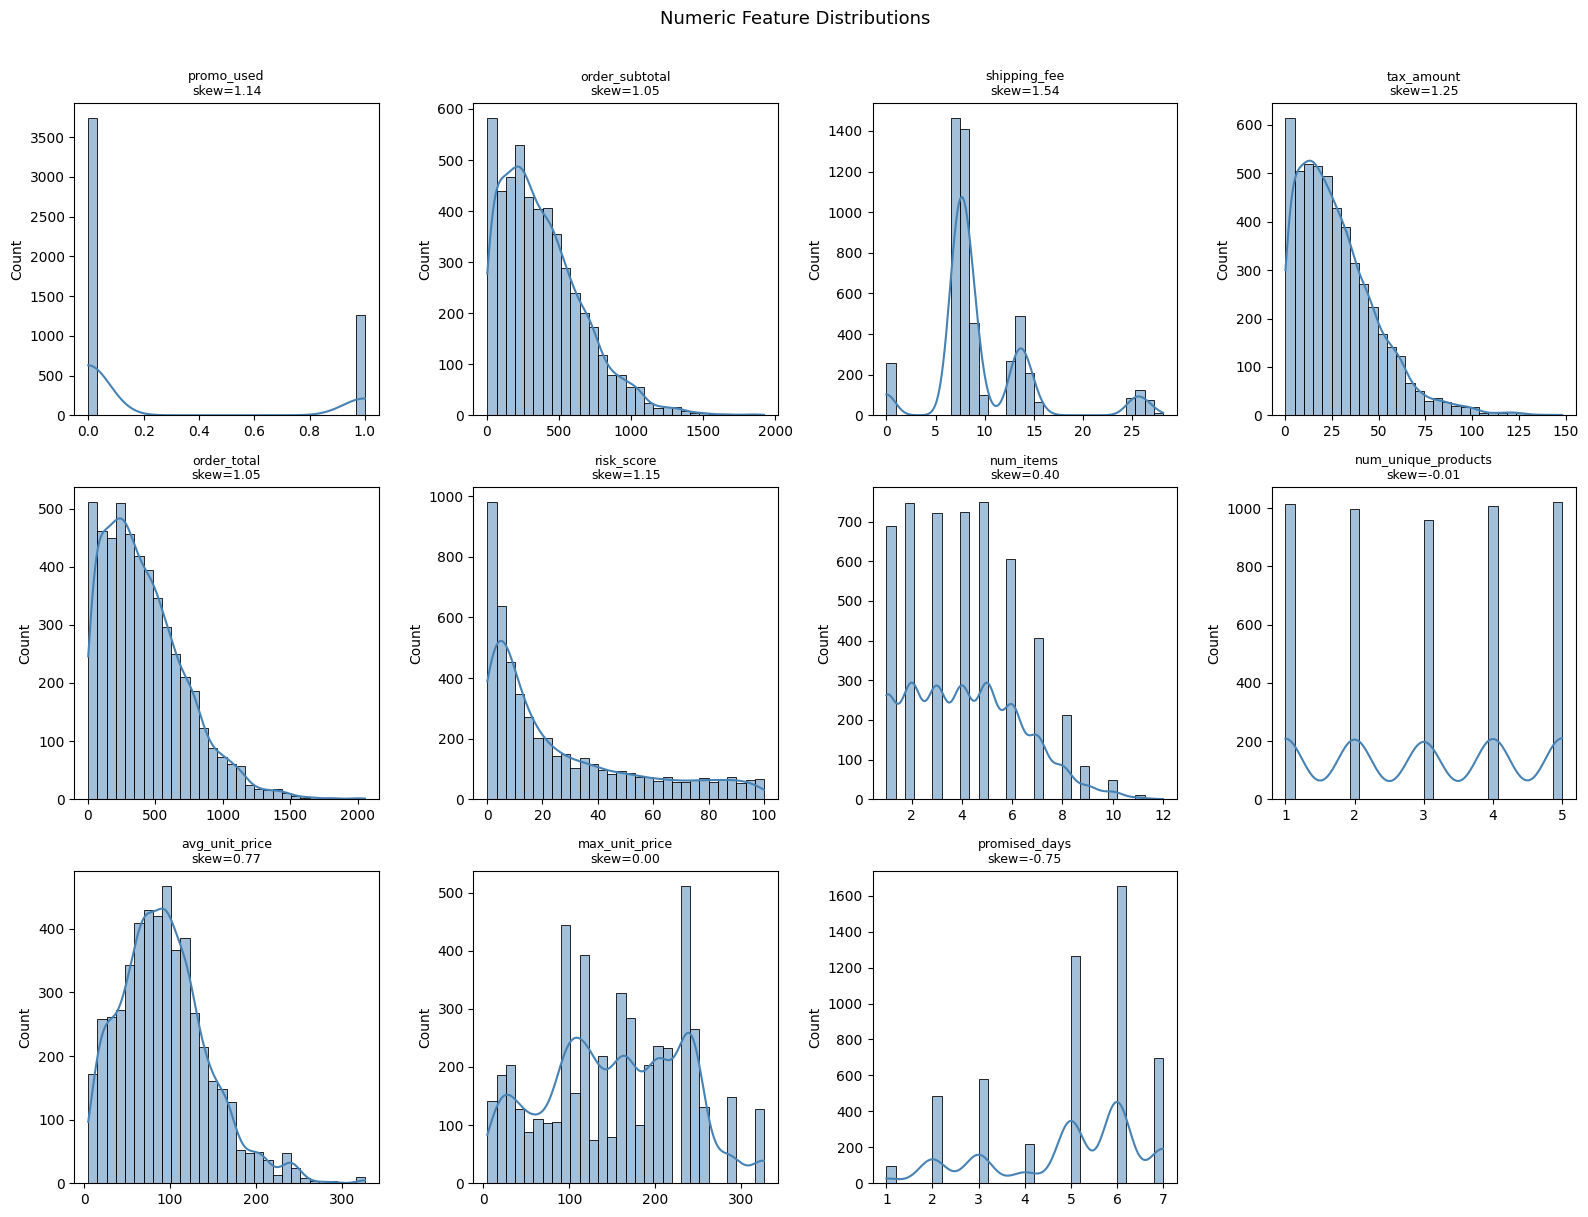

In [58]:
# 2.4a — Distribution plots: numeric features
plot_num = [c for c in us[us["type"]=="numeric"].index
            if c not in ["is_fraud","order_id","customer_id"]]

ncols = 4; nrows = (len(plot_num) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue", bins=30)
    sk = df[col].skew()
    axes[i].set_title(f"{col}\nskew={sk:.2f}", fontsize=9)
    axes[i].set_xlabel("")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

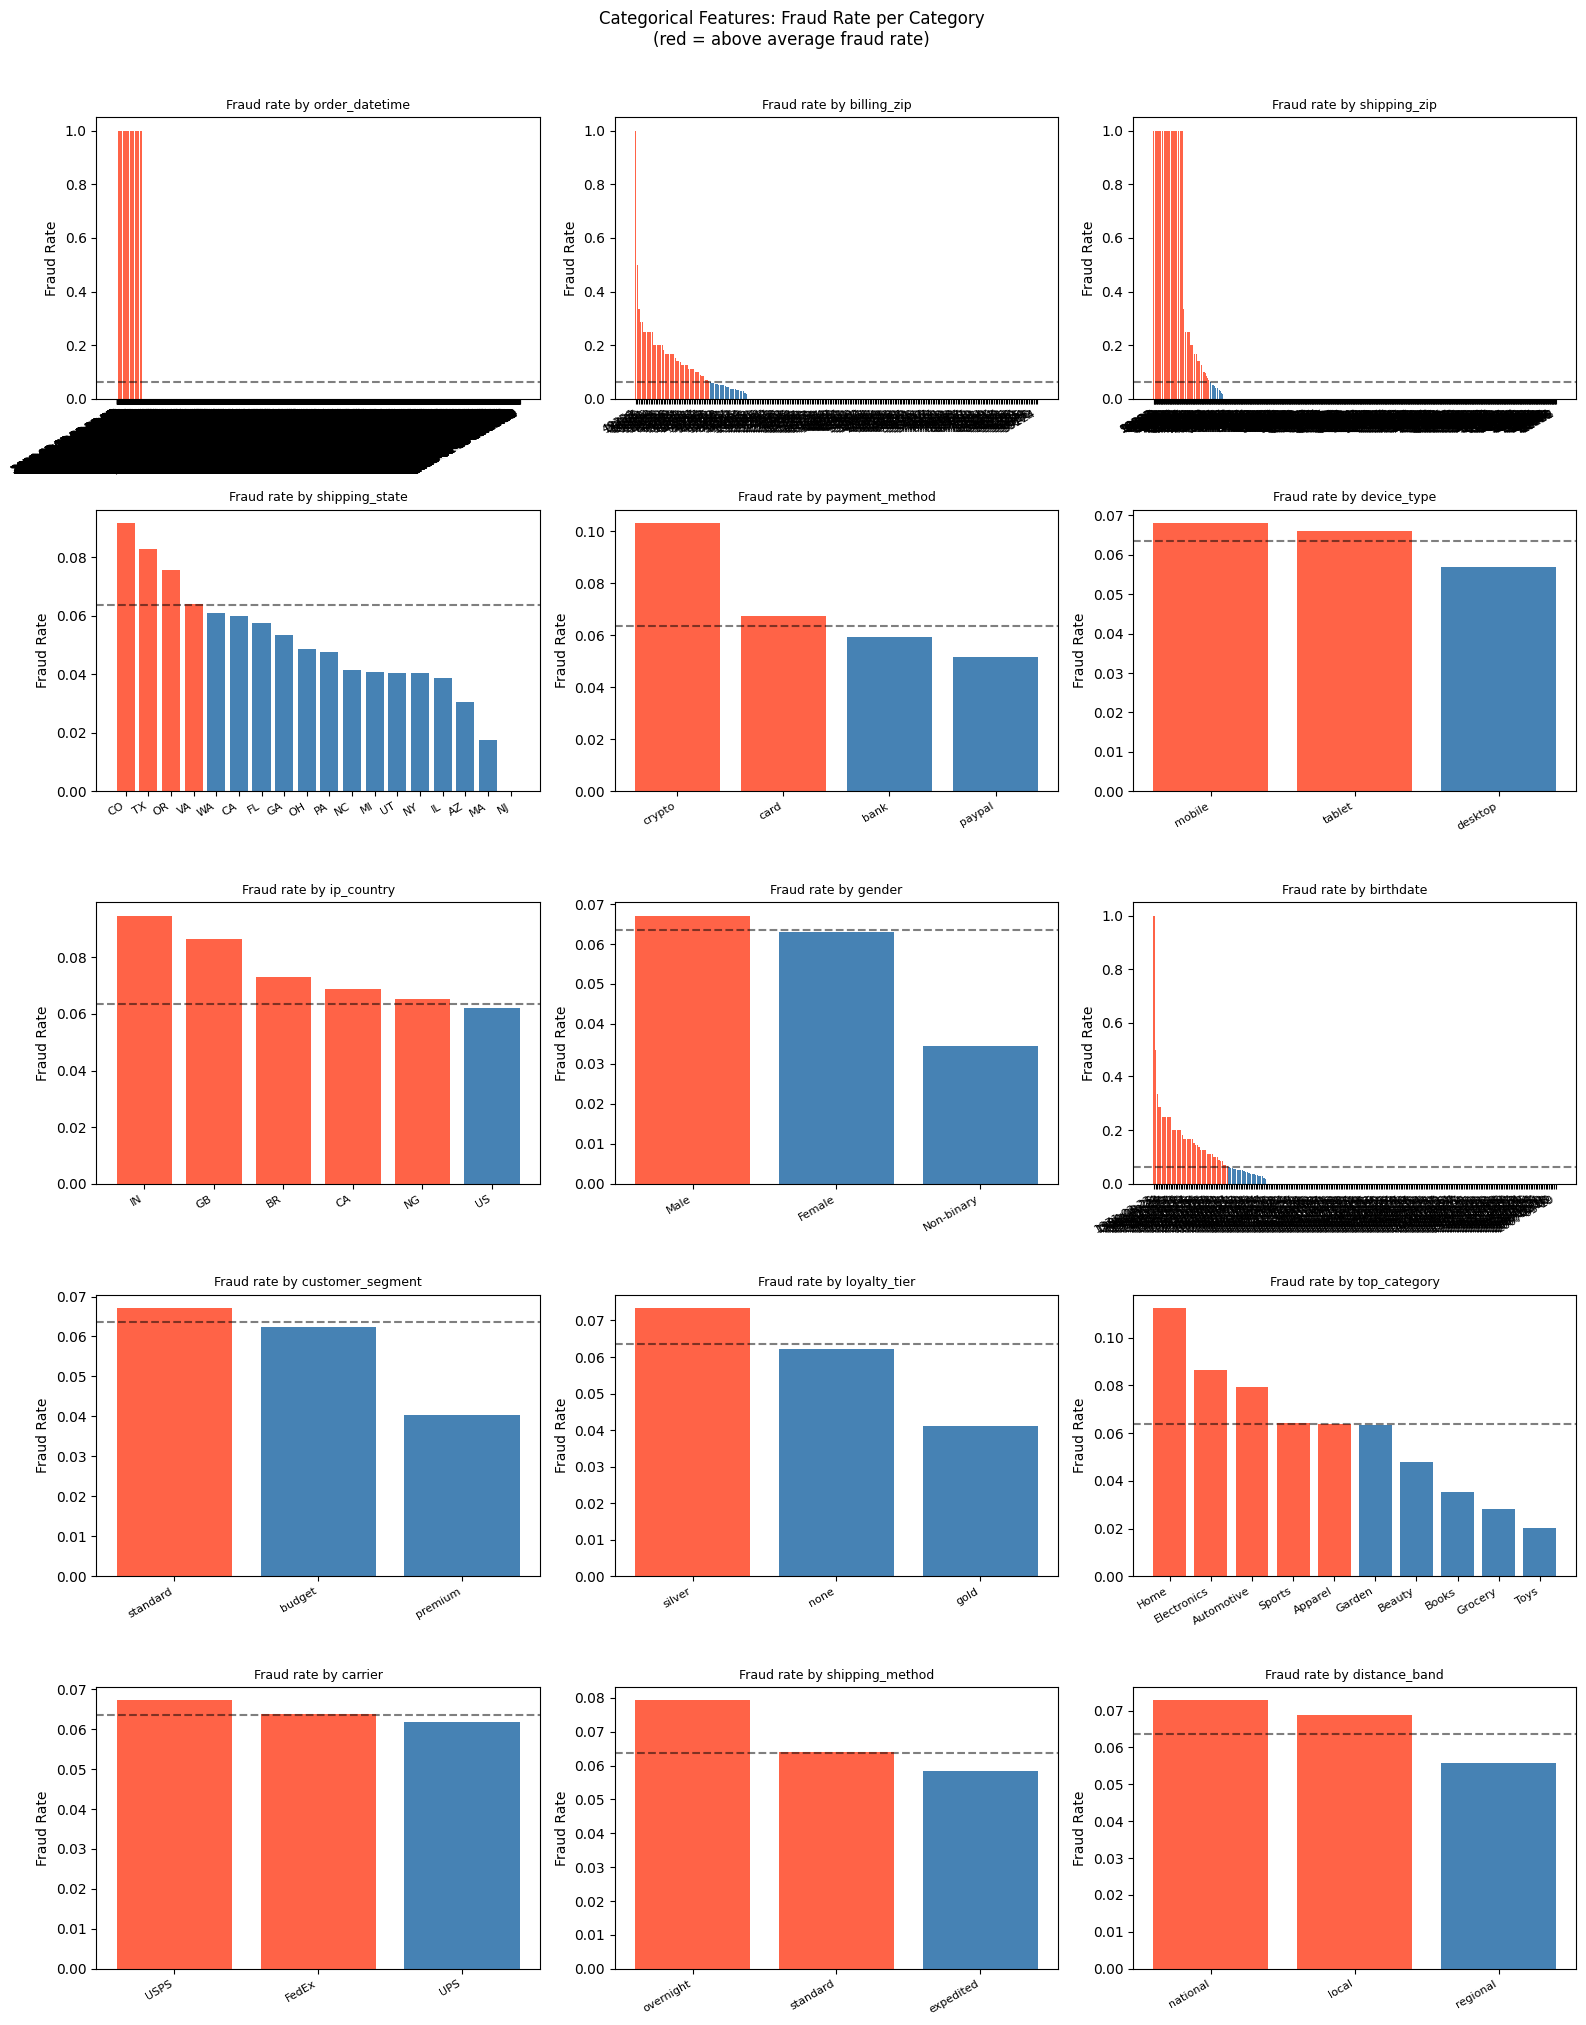

In [59]:
# 2.4b — Distribution plots: categorical features (fraud rate per category)
plot_cat = [c for c in us[us["type"]=="categorical"].index
            if c not in ["full_name","promo_code"]]

ncols = 3; nrows = (len(plot_cat) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_cat):
    fraud_rate = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    colors = ["tomato" if v > df["is_fraud"].mean() else "steelblue" for v in fraud_rate.values]
    axes[i].bar(range(len(fraud_rate)), fraud_rate.values, color=colors)
    axes[i].axhline(df["is_fraud"].mean(), color="black", linestyle="--", alpha=0.5, label="overall mean")
    axes[i].set_xticks(range(len(fraud_rate)))
    axes[i].set_xticklabels(fraud_rate.index, rotation=30, ha="right", fontsize=8)
    axes[i].set_title(f"Fraud rate by {col}", fontsize=9)
    axes[i].set_ylabel("Fraud Rate")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features: Fraud Rate per Category\n(red = above average fraud rate)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

### 2.5 — Automated Bivariate Analysis: `bivariate()` (Chapter 8)

Following **Chapter 8**, the `bivariate()` controller selects the right test based on variable pair type:

| Pair | Test | Visualization |
|------|------|---------------|
| Numeric → Numeric | Pearson r, Kendall τ, Spearman ρ via `linregress`, `kendalltau`, `spearmanr` | `sns.regplot` |
| Categorical → Numeric | One-way ANOVA via `f_oneway` | `sns.barplot` |
| Categorical → Categorical | Chi-square via `chi2_contingency` | `sns.heatmap` on crosstab |

In [60]:
# 2.5 — bivariate() function — Chapter 8 pattern
def bivariate(df, label, roundto=4, max_cats=20, visualize=False, figsize=(8, 3)):
    """
    Compute bivariate statistics for every feature vs `label`.
    Dispatches to correct test by data type: N2N, C2N/N2C, or C2C.
    Returns summary DataFrame sorted by p-value ascending.
    (Chapter 8 pattern — linregress / f_oneway / chi2_contingency)
    """
    rows = []

    for feat in df.columns:
        if feat == label:
            continue

        df_temp = df[[feat, label]].dropna()
        n_obs   = len(df_temp)
        missing_pct = round((len(df) - n_obs) / len(df), 4)

        # ─── Initialize placeholders
        p = r = F = X2 = tau = rho = None
        rel_type = "unknown"

        is_feat_num  = ptypes.is_numeric_dtype(df_temp[feat])
        is_label_num = ptypes.is_numeric_dtype(df_temp[label])

        try:
            # ── N → N ─────────────────────────────────────────
            if is_feat_num and is_label_num:
                rel_type = "N→N"
                _, _, r, p, _ = linregress(df_temp[feat], df_temp[label])
                tau, _  = kendalltau(df_temp[feat], df_temp[label])
                rho, _  = spearmanr(df_temp[feat], df_temp[label])
                r, p    = round(r, roundto), round(p, roundto)
                tau     = round(tau, roundto)
                rho     = round(rho, roundto)
                if visualize:
                    fig, ax = plt.subplots(figsize=figsize)
                    sns.regplot(x=feat, y=label, data=df_temp, ax=ax,
                                scatter_kws={"alpha":0.3,"s":15}, line_kws={"color":"red"})
                    ax.set_title(f"{feat} → {label}  |  r={r}  p={p}  n={n_obs}")
                    plt.tight_layout(); plt.show()

            # ── C → N / N → C ────────────────────────────────
            elif is_feat_num != is_label_num:
                cat_col = feat  if not is_feat_num else label
                num_col = label if not is_feat_num else feat
                rel_type = "C→N" if not is_feat_num else "N→C"
                cats = df_temp[cat_col].unique()
                if len(cats) > max_cats:
                    top  = df_temp[cat_col].value_counts().nlargest(max_cats).index
                    df_temp = df_temp[df_temp[cat_col].isin(top)]
                    cats = top
                groups = [df_temp[df_temp[cat_col]==c][num_col].values for c in cats]
                groups = [g for g in groups if len(g) >= 2]
                if len(groups) >= 2:
                    F, p = f_oneway(*groups)
                    F, p = round(F, roundto), round(p, roundto)
                if visualize:
                    fig, ax = plt.subplots(figsize=figsize)
                    ord_ = (df_temp.groupby(cat_col)[num_col]
                            .mean().sort_values(ascending=False).index.tolist())
                    sns.barplot(x=cat_col, y=num_col, data=df_temp,
                                order=ord_, ax=ax, palette="coolwarm")
                    ax.set_title(f"{cat_col} → {num_col}  |  F={F}  p={p}  n={n_obs}")
                    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
                    plt.tight_layout(); plt.show()

            # ── C → C ────────────────────────────────────────
            else:
                rel_type = "C→C"
                # Bin rare categories < 5% (Chapter 7 pattern)
                for c in [feat, label]:
                    freq = df_temp[c].value_counts(normalize=True)
                    rare = freq[freq < 0.05].index
                    df_temp = df_temp.copy()
                    df_temp[c] = df_temp[c].replace(rare, "Other")
                ct = pd.crosstab(df_temp[feat], df_temp[label])
                if ct.shape[0] >= 2 and ct.shape[1] >= 2:
                    X2, p, _, _ = chi2_contingency(ct)
                    X2, p = round(X2, roundto), round(p, roundto)
                if visualize and ct.shape[0] <= max_cats:
                    fig, ax = plt.subplots(figsize=figsize)
                    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
                    ax.set_title(f"{feat} → {label}  |  χ²={X2}  p={p}  n={n_obs}")
                    plt.tight_layout(); plt.show()

        except Exception:
            p = None

        rows.append({"feature": feat, "type": rel_type, "p": p,
                     "r (Pearson)": r, "τ (Kendall)": tau, "ρ (Spearman)": rho,
                     "F (ANOVA)": F, "χ² (Chi-sq)": X2,
                     "n_obs": n_obs, "missing_pct": missing_pct})

    return pd.DataFrame(rows).set_index("feature").sort_values("p", na_position="last")

print("✓ bivariate() defined")

✓ bivariate() defined


In [61]:
# 2.6 — Run bivariate analysis vs is_fraud
# Exclude high-cardinality PII/ID columns and raw date/zip columns
explore_drop = ["order_id","customer_id","order_datetime","birthdate",
                "billing_zip","shipping_zip","full_name","promo_code"]
df_explore = df.drop(columns=[c for c in explore_drop if c in df.columns])

print("Running bivariate() — this may take a moment...")
bv = bivariate(df_explore, label="is_fraud", visualize=False)
print(f"\n=== Bivariate Statistics vs is_fraud (sorted by p-value) ===")
display(bv)

Running bivariate() — this may take a moment...

=== Bivariate Statistics vs is_fraud (sorted by p-value) ===


,type,p,r (Pearson),τ (Kendall),ρ (Spearman),F (ANOVA),χ² (Chi-sq),n_obs,missing_pct
feature,,,,,,,,,
shipping_state,C→N,0.0000,NaN,NaN,NaN,2.9257,None,5000,0.0000
order_subtotal,N→N,0.0000,0.2065,0.1533,0.1877,NaN,None,5000,0.0000
tax_amount,N→N,0.0000,0.1957,0.1482,0.1815,NaN,None,5000,0.0000
avg_unit_price,N→N,0.0000,0.1026,0.0970,0.1188,NaN,None,5000,0.0000
num_items,N→N,0.0000,0.1412,0.1217,0.1404,NaN,None,5000,0.0000
num_unique_products,N→N,0.0000,0.1229,0.1100,0.1230,NaN,None,5000,0.0000
risk_score,N→N,0.0000,0.2701,0.2019,0.2470,NaN,None,5000,0.0000
order_total,N→N,0.0000,0.2062,0.1532,0.1877,NaN,None,5000,0.0000
top_category,C→N,0.0000,NaN,NaN,NaN,5.6360,None,5000,0.0000


Top 9 features by p-value: ['shipping_state', 'order_subtotal', 'tax_amount', 'avg_unit_price', 'num_items', 'num_unique_products', 'risk_score', 'order_total', 'top_category']

Generating bivariate visualizations...


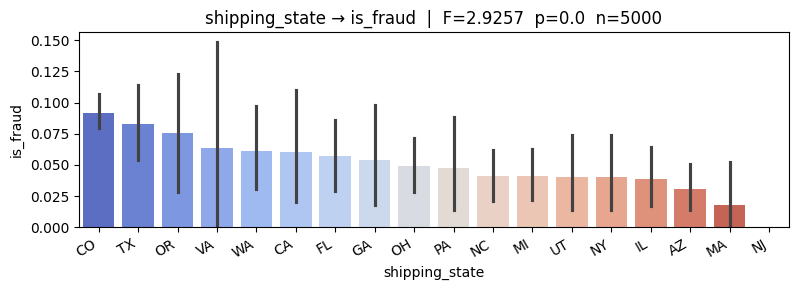

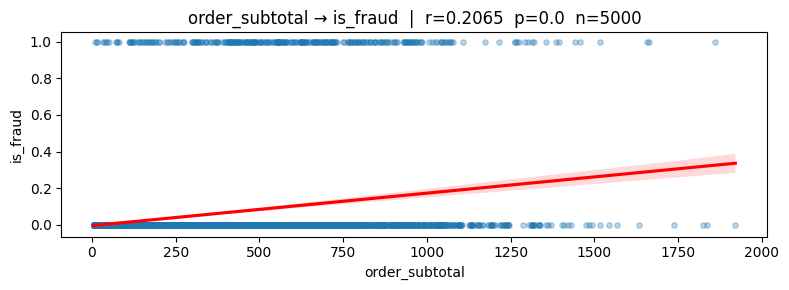

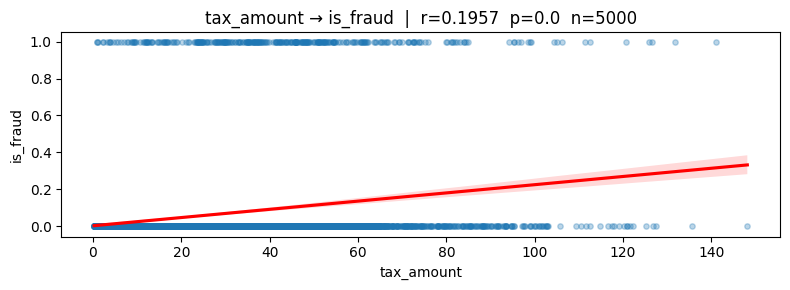

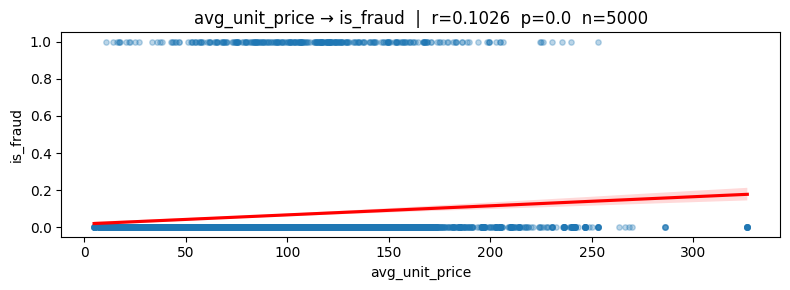

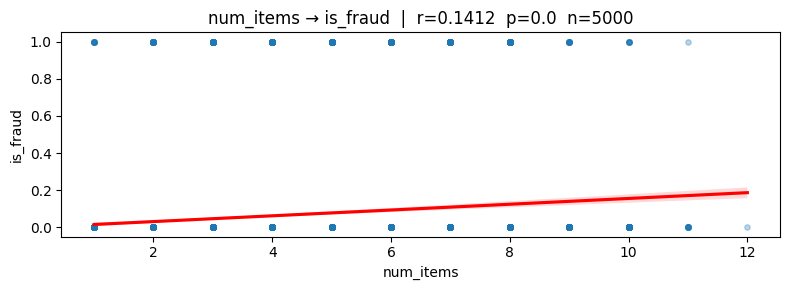

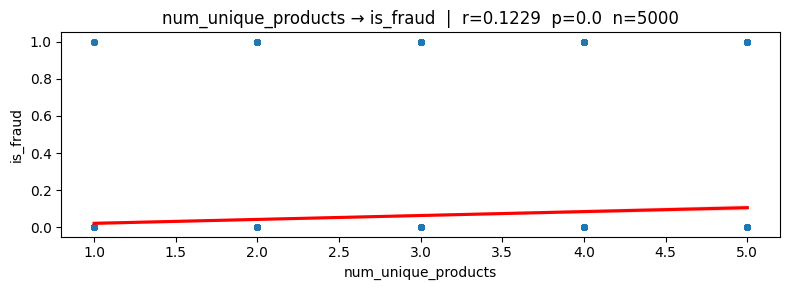

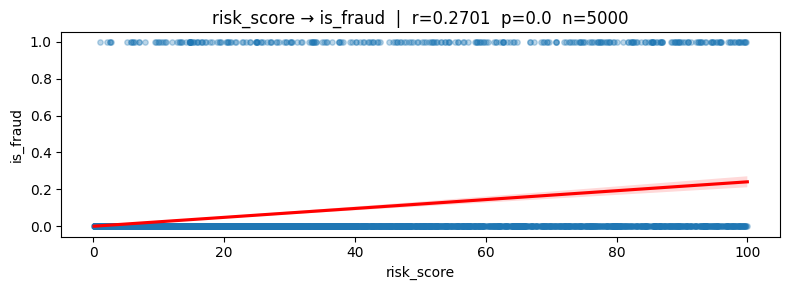

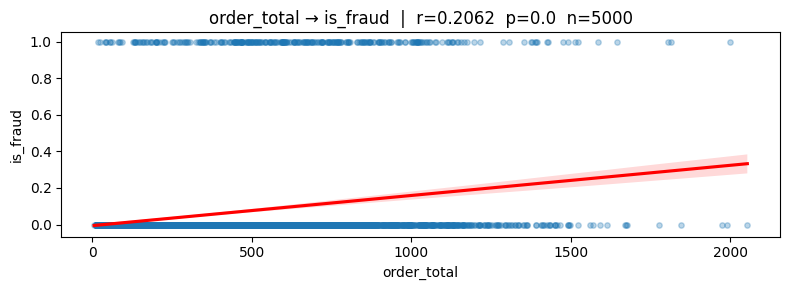

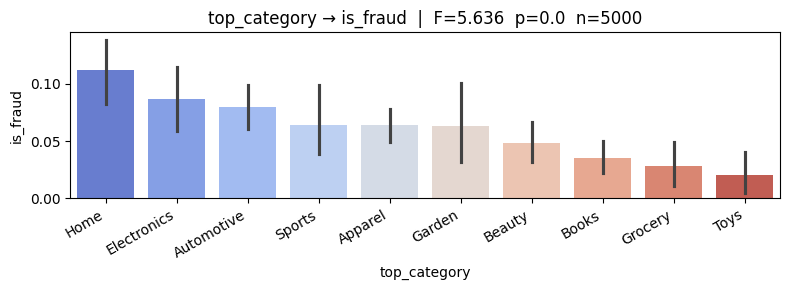

In [62]:
# 2.7 — Visualize top 9 most predictive features
top_feats = bv[bv["p"].notna()].head(9).index.tolist()
print(f"Top 9 features by p-value: {top_feats}")
print("\nGenerating bivariate visualizations...")
_ = bivariate(df_explore[top_feats + ["is_fraud"]],
              label="is_fraud", visualize=True, figsize=(8, 3))

### 2.8 — Data Understanding Summary

**Key findings from exploration:**

- `is_fraud` is highly imbalanced (~6.4% fraud). This drives the metric strategy: recall over accuracy, and use `stratify=y` in all train/test splits.
- Strong fraud signals include: `payment_method` (crypto has highest fraud rate), `same_zip` mismatch between billing and shipping, and `foreign_ip` (non-US IP address).
- `order_total`, `num_items`, and `max_unit_price` show statistically significant differences between fraud and non-fraud orders — higher-value bulk orders are riskier.
- `device_type` (mobile slightly higher) and `customer_segment` show moderate signal.
- `ip_country`, `shipping_state`, and `distance_band` will provide geographic signal through one-hot encoding.

These findings guide feature engineering and selection in Phase 3 and 5.

---
## Phase 3: Data Preparation

We clean, engineer features, and build a repeatable preparation pipeline following **Chapter 7** patterns and the **Chapter 17.4** ETL structure. The result is a clean, modeling-ready DataFrame where all transformations are documented and reproducible.

### 3.1 — Feature Engineering (Chapter 7 — Date & Derived Features)

In [63]:
# 3.1 — Start fresh from the raw joined df
df_model = df.copy()

# ── Temporal features from order_datetime ──────────────────
df_model["order_datetime"] = pd.to_datetime(df_model["order_datetime"])
df_model["order_dow"]      = df_model["order_datetime"].dt.dayofweek   # 0=Mon 6=Sun
df_model["order_month"]    = df_model["order_datetime"].dt.month
df_model["order_hour"]     = df_model["order_datetime"].dt.hour
print("✓ Temporal features: order_dow, order_month, order_hour")

# ── Customer age from birthdate ────────────────────────────
df_model["birthdate"]    = pd.to_datetime(df_model["birthdate"])
df_model["customer_age"] = datetime.now().year - df_model["birthdate"].dt.year
df_model["customer_age"] = df_model["customer_age"].clip(lower=0, upper=120)
print(f"✓ customer_age: min={df_model['customer_age'].min()}, max={df_model['customer_age'].max()}")

# ── Customer order history (how many orders has this customer placed?)
df_model["customer_order_count"] = (
    df_model.groupby("customer_id")["order_id"].transform("count")
)
print(f"✓ customer_order_count: mean={df_model['customer_order_count'].mean():.1f}")

✓ Temporal features: order_dow, order_month, order_hour
✓ customer_age: min=19, max=76
✓ customer_order_count: mean=375.7


In [64]:
# 3.2 — Fraud-signal engineered features
# These are domain-driven binary flags that directly encode known fraud patterns

# Billing zip ≠ shipping zip — a strong fraud signal
df_model["same_zip"] = (df_model["billing_zip"] == df_model["shipping_zip"]).astype(int)
print(f"✓ same_zip:   fraud rate when different: "
      f"{df_model[df_model['same_zip']==0]['is_fraud'].mean():.4f}  |  "
      f"when same: {df_model[df_model['same_zip']==1]['is_fraud'].mean():.4f}")

# Non-US IP address — orders placed from abroad
df_model["foreign_ip"] = (df_model["ip_country"] != "US").astype(int)
print(f"✓ foreign_ip: fraud rate for foreign: "
      f"{df_model[df_model['foreign_ip']==1]['is_fraud'].mean():.4f}  |  "
      f"domestic: {df_model[df_model['foreign_ip']==0]['is_fraud'].mean():.4f}")

# promo_used is already 0/1 — kept as-is
print(f"✓ promo_used: fraud rate with promo: "
      f"{df_model[df_model['promo_used']==1]['is_fraud'].mean():.4f}  |  "
      f"without: {df_model[df_model['promo_used']==0]['is_fraud'].mean():.4f}")

✓ same_zip:   fraud rate when different: 0.1173  |  when same: 0.0590
✓ foreign_ip: fraud rate for foreign: 0.0774  |  domestic: 0.0621
✓ promo_used: fraud rate with promo: 0.0682  |  without: 0.0620


### 3.2 — Define the Leakage-Free Feature Set

Before cleaning, we explicitly list which columns are features, which is the target, and which to drop. This discipline prevents subtle leakage — the most common cause of deployment failures (Chapter 17).

In [65]:
# 3.3 — Drop leakage columns, IDs, and raw date columns
# Any column that would be unknown at the time of order placement is leakage.
LEAKAGE_COLS = [
    # IDs — not features
    "order_id", "customer_id",
    # Raw dates — replaced by engineered temporal features
    "order_datetime", "birthdate",
    # Raw zip codes — replaced by same_zip engineered feature
    "billing_zip", "shipping_zip",
    # PII — not predictive
    "full_name",
    # Text promo code — captured as binary promo_used; high-cardinality text
    "promo_code",
    # CO-TARGET: risk_score is the other prediction target from Section 17.10
    # Using it to predict is_fraud would be target leakage
    "risk_score",
]
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df_model.columns]
df_model.drop(columns=LEAKAGE_COLS, inplace=True)
print(f"Dropped {len(LEAKAGE_COLS)} leakage/ID columns: {LEAKAGE_COLS}")
print(f"Remaining columns ({df_model.shape[1]}): {df_model.columns.tolist()}")

Dropped 9 leakage/ID columns: ['order_id', 'customer_id', 'order_datetime', 'birthdate', 'billing_zip', 'shipping_zip', 'full_name', 'promo_code', 'risk_score']
Remaining columns (29): ['shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'is_fraud', 'gender', 'customer_segment', 'loyalty_tier', 'num_items', 'num_unique_products', 'avg_unit_price', 'max_unit_price', 'top_category', 'carrier', 'shipping_method', 'distance_band', 'promised_days', 'order_dow', 'order_month', 'order_hour', 'customer_age', 'customer_order_count', 'same_zip', 'foreign_ip']


In [66]:
# 3.4 — Basic wrangling: remove near-empty and near-constant columns (Chapter 7 pattern)
def basic_wrangling(df, missing_threshold=0.95, unique_threshold=0.98, messages=True):
    """
    Drop columns with:
      - Too many missing values (> missing_threshold fraction)
      - Too many unique values for categoricals (> unique_threshold — ID-like)
    (Chapter 7 basic_wrangling() pattern)
    """
    dropped = []
    for col in list(df.columns):
        miss_pct   = df[col].isna().sum() / len(df)
        unique_pct = df[col].nunique()    / len(df)
        if miss_pct >= missing_threshold:
            df.drop(columns=[col], inplace=True)
            dropped.append((col, f"missing={miss_pct:.1%}"))
        elif not ptypes.is_numeric_dtype(df[col]) and unique_pct >= unique_threshold:
            df.drop(columns=[col], inplace=True)
            dropped.append((col, f"unique={unique_pct:.1%}"))
    if messages:
        if dropped:
            for d in dropped: print(f"  Dropped: {d[0]} ({d[1]})")
        else:
            print("  No columns dropped by basic_wrangling.")
    return df

df_model = basic_wrangling(df_model.copy())
print(f"Shape after basic_wrangling: {df_model.shape}")

  No columns dropped by basic_wrangling.
Shape after basic_wrangling: (5000, 29)


In [67]:
# 3.5 — Missing value analysis (Chapter 7 pattern)
miss = df_model.isna().sum()
miss_pct = (miss / len(df_model)).round(4)
miss_report = pd.DataFrame({"missing": miss, "pct": miss_pct})
miss_report = miss_report[miss_report["missing"] > 0].sort_values("pct", ascending=False)

if miss_report.empty:
    print("✓ No missing values detected after wrangling.")
else:
    print("Columns with missing values:")
    display(miss_report)
    print("\nStrategy: handled inside sklearn Pipeline via SimpleImputer(strategy='median'/'most_frequent')")

✓ No missing values detected after wrangling.


In [68]:
# 3.6 — Rare category binning (Chapter 7 — 5% rule)
def bin_rare_categories(df, threshold=0.05, messages=True):
    """
    Replace any category appearing in < threshold fraction of rows with 'Other'.
    (Chapter 7 — 5% rule for categorical binning)
    """
    for col in df.select_dtypes(include=["object", "category"]).columns:
        freq = df[col].value_counts(normalize=True)
        rare = freq[freq < threshold].index.tolist()
        if rare:
            df[col] = df[col].replace(rare, "Other")
            if messages:
                print(f"  {col}: grouped {len(rare)} rare categories → 'Other'  "
                      f"(rare: {rare})")
    return df

print("Rare category binning (threshold=5%):")
df_model = bin_rare_categories(df_model.copy())

Rare category binning (threshold=5%):
  shipping_state: grouped 12 rare categories → 'Other'  (rare: ['FL', 'IL', 'WA', 'NY', 'UT', 'PA', 'GA', 'OR', 'CA', 'MA', 'NJ', 'VA'])
  payment_method: grouped 1 rare categories → 'Other'  (rare: ['crypto'])
  ip_country: grouped 5 rare categories → 'Other'  (rare: ['CA', 'GB', 'IN', 'NG', 'BR'])
  gender: grouped 1 rare categories → 'Other'  (rare: ['Non-binary'])
  top_category: grouped 3 rare categories → 'Other'  (rare: ['Sports', 'Toys', 'Garden'])


In [69]:
# 3.7 — Skewness check and correction (Chapter 7 pattern)
def skew_check(df, threshold=1.0, messages=True):
    """
    For numeric columns with |skew| > threshold:
    - Test log1p, sqrt, cbrt, Yeo-Johnson transformations
    - Select the one that minimizes absolute skewness
    - Add *_skewfix column; original column retained for comparison
    (Chapter 7 skew_correct() pattern)
    """
    for col in df.select_dtypes(include=[np.number]).columns:
        if col in ["is_fraud","same_zip","foreign_ip","promo_used","order_dow",
                   "order_month","order_hour","customer_order_count"]:
            continue  # skip binary/ordinal/count features
        s = df[col].dropna()
        if len(s) < 10:
            continue
        orig_skew = abs(s.skew())
        if orig_skew < threshold:
            continue

        candidates = {"none": orig_skew}
        if s.min() >= 0:
            candidates["log1p"] = abs(np.log1p(s).skew())
            candidates["sqrt"]  = abs(np.sqrt(s).skew())
        candidates["cbrt"]      = abs(np.cbrt(s).skew())
        yt, _ = yeojohnson(s.fillna(s.median()))
        candidates["yeojohnson"] = abs(pd.Series(yt).skew())

        best = min(candidates, key=candidates.get)
        if best == "none":
            continue

        if messages:
            print(f"  {col}: |skew|={orig_skew:.2f} → {best} gives |skew|={candidates[best]:.2f}")

        if best == "log1p":
            df[f"{col}_skewfix"] = np.log1p(df[col].clip(lower=0))
        elif best == "sqrt":
            df[f"{col}_skewfix"] = np.sqrt(df[col].clip(lower=0))
        elif best == "cbrt":
            df[f"{col}_skewfix"] = np.cbrt(df[col])
        elif best == "yeojohnson":
            t, _ = yeojohnson(df[col].fillna(df[col].median()))
            df[f"{col}_skewfix"] = t
    return df

print("Skewness corrections:")
df_model = skew_check(df_model.copy())
print(f"\nShape after skewness correction: {df_model.shape}")

Skewness corrections:
  order_subtotal: |skew|=1.05 → sqrt gives |skew|=0.07
  shipping_fee: |skew|=1.54 → yeojohnson gives |skew|=0.25
  tax_amount: |skew|=1.25 → yeojohnson gives |skew|=0.06
  order_total: |skew|=1.05 → yeojohnson gives |skew|=0.08
  customer_age: |skew|=1.22 → yeojohnson gives |skew|=0.32

Shape after skewness correction: (5000, 34)


In [70]:
# 3.8 — Define the final feature list and target
# NOTE: We exclude the _skewfix documentation columns from ALL_FEATURES.
# The sklearn Pipeline's StandardScaler handles scale/skew during training and inference.
# Keeping raw + skewfix would double-count features and complicate the inference path.
LABEL_COL = "is_fraud"

ALL_FEATURES = [c for c in df_model.columns
                if c != LABEL_COL and not c.endswith("_skewfix")]
NUMERIC_FEATURES     = [c for c in ALL_FEATURES if ptypes.is_numeric_dtype(df_model[c])]
CATEGORICAL_FEATURES = [c for c in ALL_FEATURES if not ptypes.is_numeric_dtype(df_model[c])]

print(f"Target:  {LABEL_COL}")
print(f"\nNumeric features ({len(NUMERIC_FEATURES)}):")
for f in NUMERIC_FEATURES: print(f"  {f}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}):")
for f in CATEGORICAL_FEATURES: print(f"  {f}")

X = df_model[ALL_FEATURES].copy()
y = df_model[LABEL_COL].astype(int)
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"Class balance: {y.value_counts(normalize=True).round(4).to_dict()}")

Target:  is_fraud

Numeric features (17):
  promo_used
  order_subtotal
  shipping_fee
  tax_amount
  order_total
  num_items
  num_unique_products
  avg_unit_price
  max_unit_price
  promised_days
  order_dow
  order_month
  order_hour
  customer_age
  customer_order_count
  same_zip
  foreign_ip

Categorical features (11):
  shipping_state
  payment_method
  device_type
  ip_country
  gender
  customer_segment
  loyalty_tier
  top_category
  carrier
  shipping_method
  distance_band

X shape: (5000, 28)  |  y shape: (5000,)
Class balance: {0: 0.9364, 1: 0.0636}


In [71]:
# 3.9 — Reusable prepare_data() function for deployment scripts
# This function is imported by jobs/run_inference.py to guarantee
# training and inference use IDENTICAL feature engineering. (Ch. 17 principle)

def prepare_data(orders_df, customers_df, order_items_df, products_df, shipments_df):
    """
    Full data preparation pipeline:
      ETL join → feature engineering → leakage removal → rare-category binning
    Returns: (X, y, numeric_features, categorical_features)
    Import this in deployment inference scripts for consistent preprocessing.
    """
    # ── ETL
    oagg = (order_items_df.groupby("order_id")
            .agg(num_items=("quantity","sum"),
                 num_unique_products=("product_id","nunique"),
                 avg_unit_price=("unit_price","mean"),
                 max_unit_price=("unit_price","max"))
            .reset_index())
    ocats = (order_items_df.merge(products_df[["product_id","category"]], on="product_id", how="left")
             .groupby("order_id")["category"]
             .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
             .reset_index().rename(columns={"category":"top_category"}))
    sfeats = shipments_df[["order_id","carrier","shipping_method","distance_band","promised_days"]]
    df = (orders_df
          .merge(customers_df[["customer_id","full_name","gender","birthdate",
                                "customer_segment","loyalty_tier"]], on="customer_id", how="left")
          .merge(oagg,    on="order_id", how="left")
          .merge(ocats,   on="order_id", how="left")
          .merge(sfeats,  on="order_id", how="left"))
    # ── Feature engineering
    df["order_datetime"]      = pd.to_datetime(df["order_datetime"])
    df["birthdate"]           = pd.to_datetime(df["birthdate"])
    df["order_dow"]           = df["order_datetime"].dt.dayofweek
    df["order_month"]         = df["order_datetime"].dt.month
    df["order_hour"]          = df["order_datetime"].dt.hour
    df["customer_age"]        = (datetime.now().year - df["birthdate"].dt.year).clip(0, 120)
    df["customer_order_count"]= df.groupby("customer_id")["order_id"].transform("count")
    df["same_zip"]            = (df["billing_zip"] == df["shipping_zip"]).astype(int)
    df["foreign_ip"]          = (df["ip_country"] != "US").astype(int)
    # ── Drop leakage
    drop_cols = ["order_id","customer_id","order_datetime","birthdate",
                 "billing_zip","shipping_zip","full_name","promo_code","risk_score"]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    # ── Separate
    label = "is_fraud"
    feat_cols = [c for c in df.columns if c != label]
    num_feats = [c for c in feat_cols if ptypes.is_numeric_dtype(df[c])]
    cat_feats = [c for c in feat_cols if not ptypes.is_numeric_dtype(df[c])]
    X_out = df[feat_cols].copy()
    y_out = df[label].astype(int) if label in df.columns else None
    return X_out, y_out, num_feats, cat_feats

print("✓ prepare_data() defined — ready for import by deployment scripts")

✓ prepare_data() defined — ready for import by deployment scripts


---
## Phase 4: Modeling

We build and train three classification models using `sklearn.pipeline.Pipeline` — packaging preprocessing and the model into a single serializable artifact. This is the core deployment pattern from **Chapter 17.5**: *the same Pipeline object handles training and inference*.

In [72]:
# 4.1 — Stratified train/test split
# stratify=y is CRITICAL for imbalanced fraud data (Ch. 13, Ch. 17)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train fraud rate: {y_train.mean():.4f}  |  Test fraud rate: {y_test.mean():.4f}")

Train: 4,000 rows  |  Test: 1,000 rows
Train fraud rate: 0.0635  |  Test fraud rate: 0.0640


In [73]:
# 4.2 — Preprocessing pipeline (Chapter 17.5 ColumnTransformer pattern)
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,      NUMERIC_FEATURES),
        ("cat", categorical_pipe,  CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)
print("✓ Preprocessor built")
print(f"   Numeric features  ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"   Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

✓ Preprocessor built
   Numeric features  (17): ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'num_items', 'num_unique_products', 'avg_unit_price', 'max_unit_price', 'promised_days', 'order_dow', 'order_month', 'order_hour', 'customer_age', 'customer_order_count', 'same_zip', 'foreign_ip']
   Categorical features (11): ['shipping_state', 'payment_method', 'device_type', 'ip_country', 'gender', 'customer_segment', 'loyalty_tier', 'top_category', 'carrier', 'shipping_method', 'distance_band']


### 4.3 — Model 1: Logistic Regression (Baseline) — Chapter 13

Logistic Regression is our interpretable baseline. It provides calibrated probabilities and sets the performance floor for ensemble comparisons.

In [74]:
# 4.3 — Logistic Regression baseline (Chapter 13)
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression — Test Set ===")
print(classification_report(y_test, y_pred_lr,
      target_names=["Legitimate (0)","Fraud (1)"], zero_division=0))
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_lr):.4f}")

=== Logistic Regression — Test Set ===
                precision    recall  f1-score   support

Legitimate (0)       0.94      1.00      0.97       936
     Fraud (1)       0.25      0.02      0.03        64

      accuracy                           0.93      1000
     macro avg       0.59      0.51      0.50      1000
  weighted avg       0.89      0.93      0.91      1000

ROC AUC:  0.7661
Log Loss: 0.2137


### 4.4 — Model 2: Random Forest — Chapter 14 (Bagging Ensemble)

Random Forest trains many decorrelated trees and averages their predictions. It handles non-linear relationships and feature interactions — both common in fraud patterns.

In [75]:
# 4.4 — Random Forest (Chapter 14 — bagging ensemble)
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(
                n_estimators=200, max_depth=None,
                min_samples_leaf=1, n_jobs=-1, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf  = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest — Test Set ===")
print(classification_report(y_test, y_pred_rf,
      target_names=["Legitimate (0)","Fraud (1)"], zero_division=0))
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_rf):.4f}")

=== Random Forest — Test Set ===
                precision    recall  f1-score   support

Legitimate (0)       0.94      1.00      0.97       936
     Fraud (1)       0.00      0.00      0.00        64

      accuracy                           0.93      1000
     macro avg       0.47      0.50      0.48      1000
  weighted avg       0.88      0.93      0.90      1000

ROC AUC:  0.7287
Log Loss: 0.2511


### 4.5 — Model 3: Gradient Boosting — Chapter 14 (Sequential Ensemble)

Gradient Boosting builds trees sequentially, each correcting the errors of the previous. It typically achieves the highest accuracy but is slower to train.

In [76]:
# 4.5 — Gradient Boosting (Chapter 14 — sequential ensemble)
gb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",  GradientBoostingClassifier(
                n_estimators=200, max_depth=3,
                learning_rate=0.1, random_state=42))
])
gb_pipeline.fit(X_train, y_train)

y_pred_gb  = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting — Test Set ===")
print(classification_report(y_test, y_pred_gb,
      target_names=["Legitimate (0)","Fraud (1)"], zero_division=0))
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_gb):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_gb):.4f}")

=== Gradient Boosting — Test Set ===
                precision    recall  f1-score   support

Legitimate (0)       0.94      0.99      0.96       936
     Fraud (1)       0.10      0.02      0.03        64

      accuracy                           0.93      1000
     macro avg       0.52      0.50      0.49      1000
  weighted avg       0.88      0.93      0.90      1000

ROC AUC:  0.7287
Log Loss: 0.2337


In [77]:
# 4.6 — Model comparison table (Chapter 14 pattern)
results = []
for name, yp, ypr in [("Logistic Regression", y_pred_lr, y_proba_lr),
                       ("Random Forest",       y_pred_rf, y_proba_rf),
                       ("Gradient Boosting",   y_pred_gb, y_proba_gb)]:
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, yp),                    4),
        "Precision": round(precision_score(y_test, yp, zero_division=0),  4),
        "Recall":    round(recall_score(y_test, yp,    zero_division=0),  4),
        "F1":        round(f1_score(y_test, yp,        zero_division=0),  4),
        "ROC AUC":   round(roc_auc_score(y_test, ypr),                   4),
        "Log Loss":  round(log_loss(y_test, ypr),                        4),
    })
comp = pd.DataFrame(results).set_index("Model")
print("=== Model Comparison (Test Set) ===")
display(comp.style
        .highlight_max(subset=["Accuracy","Precision","Recall","F1","ROC AUC"], color="lightgreen")
        .highlight_min(subset=["Log Loss"], color="lightgreen"))

=== Model Comparison (Test Set) ===


,Accuracy,Precision,Recall,F1,ROC AUC,Log Loss
Model,,,,,,
Logistic Regression,0.934000,0.250000,0.015600,0.029400,0.766100,0.213700
Random Forest,0.933000,0.000000,0.000000,0.000000,0.728700,0.251100
Gradient Boosting,0.928000,0.100000,0.015600,0.027000,0.728700,0.233700


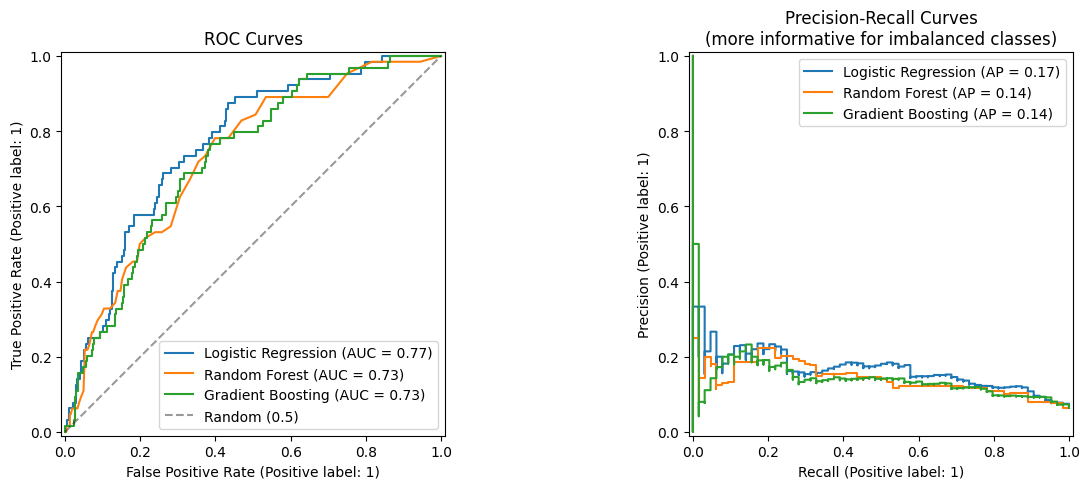

In [78]:
# 4.7 — ROC and PR curve comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, ypr in [("Logistic Regression", y_proba_lr),
                  ("Random Forest",       y_proba_rf),
                  ("Gradient Boosting",   y_proba_gb)]:
    RocCurveDisplay.from_predictions(y_test, ypr, name=name, ax=ax1)
ax1.plot([0,1],[0,1],"k--",alpha=0.4,label="Random (0.5)")
ax1.set_title("ROC Curves"); ax1.legend(loc="lower right")

for name, ypr in [("Logistic Regression", y_proba_lr),
                  ("Random Forest",       y_proba_rf),
                  ("Gradient Boosting",   y_proba_gb)]:
    PrecisionRecallDisplay.from_predictions(y_test, ypr, name=name, ax=ax2)
ax2.set_title("Precision-Recall Curves\n(more informative for imbalanced classes)")
ax2.legend(loc="upper right")

plt.tight_layout(); plt.show()

---
## Phase 5: Evaluation, Feature Selection & Tuning

We apply rigorous evaluation following **Chapter 15** (cross-validation, learning curves, GridSearchCV) and **Chapter 16** (filter, wrapper, and permutation-based feature selection).

### 5.1 — Cross-Validation with StratifiedKFold (Chapter 15)

In [79]:
# 5.1 — 5-fold Stratified CV with multi-metric scoring (Chapter 15)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc", "f1": "f1",
           "precision": "precision", "recall": "recall", "neg_log_loss": "neg_log_loss"}

# Pick the model with best initial AUC — update if GB was better
candidate_name = "Random Forest"
candidate      = rf_pipeline

print(f"Running 5-fold CV on {candidate_name}...")
cv_res = cross_validate(candidate, X_train, y_train, cv=skf,
                        scoring=scoring, n_jobs=-1, return_train_score=True)

summary_rows = []
for m in ["accuracy","roc_auc","f1","precision","recall"]:
    summary_rows.append({
        "Metric":      m,
        "Val Mean":    round(cv_res[f"test_{m}"].mean(),  4),
        "Val Std":     round(cv_res[f"test_{m}"].std(),   4),
        "Train Mean":  round(cv_res[f"train_{m}"].mean(), 4),
    })
summary_rows.append({
    "Metric":      "log_loss",
    "Val Mean":    round(-cv_res["test_neg_log_loss"].mean(),  4),
    "Val Std":     round(cv_res["test_neg_log_loss"].std(),    4),
    "Train Mean":  round(-cv_res["train_neg_log_loss"].mean(), 4),
})
print(f"\n=== 5-Fold CV: {candidate_name} ===")
display(pd.DataFrame(summary_rows).set_index("Metric"))

Running 5-fold CV on Random Forest...

=== 5-Fold CV: Random Forest ===


,Val Mean,Val Std,Train Mean
Metric,,,
accuracy,0.9358,0.0013,1.0000
roc_auc,0.7253,0.0252,1.0000
f1,0.0000,0.0000,1.0000
precision,0.0000,0.0000,1.0000
recall,0.0000,0.0000,1.0000
log_loss,0.2353,0.0232,0.0490


### 5.2 — Learning Curve (Chapter 15)

Learning curves diagnose whether the model has **high bias** (both curves low — underfit) or **high variance** (large gap between train and val — overfit).

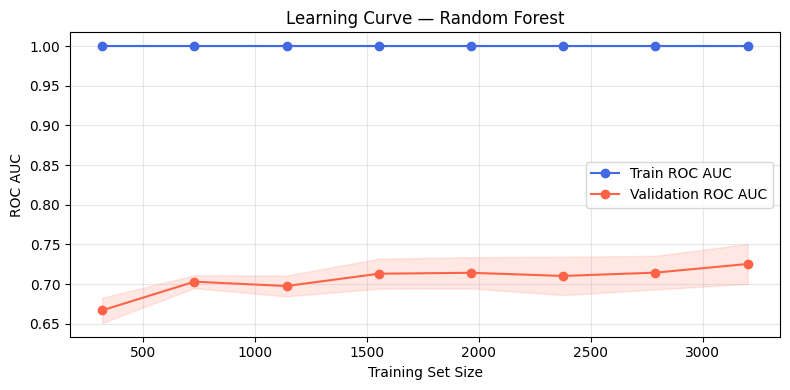

Train AUC (full data): 1.0000
Val   AUC (full data): 0.7253
Gap: 0.2747 → High Variance (overfitting)


In [80]:
# 5.2 — Learning curve (Chapter 15)
train_sizes, train_scores, val_scores = learning_curve(
    candidate, X_train, y_train,
    cv=skf, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, train_scores.mean(1), "o-", color="royalblue", label="Train ROC AUC")
ax.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1),
                             train_scores.mean(1)+train_scores.std(1), alpha=0.15, color="royalblue")
ax.plot(train_sizes, val_scores.mean(1), "o-", color="tomato", label="Validation ROC AUC")
ax.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1),
                             val_scores.mean(1)+val_scores.std(1), alpha=0.15, color="tomato")
ax.set_xlabel("Training Set Size"); ax.set_ylabel("ROC AUC")
ax.set_title(f"Learning Curve — {candidate_name}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
print(f"Train AUC (full data): {train_scores.mean(1)[-1]:.4f}")
print(f"Val   AUC (full data): {val_scores.mean(1)[-1]:.4f}")
print(f"Gap: {gap:.4f} → {'High Variance (overfitting)' if gap > 0.05 else 'Well balanced'}")

### 5.3 — Feature Selection (Chapter 16)

Three methods evaluated:
1. **Filter (SelectKBest)** — fast univariate ranking, no model required
2. **Permutation Importance** — model-agnostic, computed on test set (avoids leakage)
3. **RFECV** — wrapper method that finds the optimal feature subset via cross-validation

In [81]:
# 5.3a — Fit preprocessor and get feature names
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

try:
    feature_names_out = list(preprocessor.get_feature_names_out())
except Exception:
    n_num = len(NUMERIC_FEATURES)
    n_cat = X_train_prep.shape[1] - n_num
    feature_names_out = ([f"num__{f}" for f in NUMERIC_FEATURES] +
                         [f"cat__{i}" for i in range(n_cat)])

print(f"Total preprocessed features: {len(feature_names_out)}")

# SelectKBest (Chapter 16 — filter method)
k = min(20, X_train_prep.shape[1])
skb = SelectKBest(score_func=f_classif, k=k)
skb.fit(X_train_prep, y_train)
scores_df = (pd.DataFrame({"Feature": feature_names_out, "F-Score": skb.scores_})
             .sort_values("F-Score", ascending=False))
print(f"\nTop {k} features by SelectKBest(f_classif):")
display(scores_df.head(k).reset_index(drop=True))

Total preprocessed features: 59

Top 20 features by SelectKBest(f_classif):


,Feature,F-Score
0,num__order_subtotal,191.3185
1,num__order_total,191.0232
2,num__tax_amount,173.2885
3,num__num_items,101.0505
4,num__max_unit_price,76.7403
5,num__num_unique_products,76.3168
6,num__customer_order_count,39.5902
7,num__avg_unit_price,39.3316
8,cat__shipping_state_CO,24.6217
9,num__customer_age,21.9075


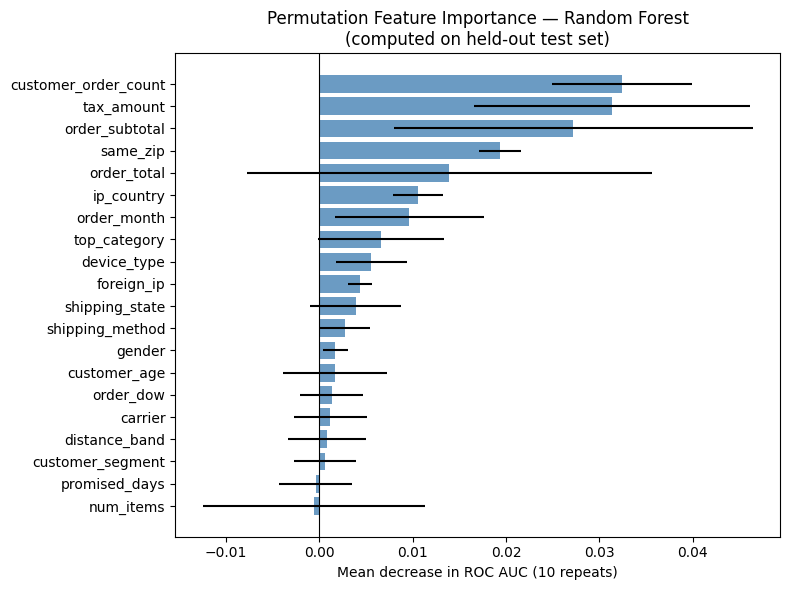

Top 10 features by permutation importance:


,Feature,Importance,Std
0,customer_order_count,0.0324,0.0075
1,tax_amount,0.0314,0.0148
2,order_subtotal,0.0272,0.0192
3,same_zip,0.0194,0.0023
4,order_total,0.0139,0.0217
5,ip_country,0.0106,0.0026
6,order_month,0.0097,0.0080
7,top_category,0.0066,0.0067
8,device_type,0.0055,0.0038
9,foreign_ip,0.0044,0.0012


In [82]:
# 5.3b — Permutation Feature Importance (Chapter 16 — model-agnostic, post-hoc)
pfi = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10, scoring="roc_auc",
    n_jobs=-1, random_state=42
)
pfi_df = (pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": pfi.importances_mean,
    "Std":        pfi.importances_std,
}).sort_values("Importance", ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
top20 = pfi_df.head(20)
ax.barh(top20["Feature"][::-1], top20["Importance"][::-1],
        xerr=top20["Std"][::-1], color="steelblue", alpha=0.8)
ax.set_xlabel("Mean decrease in ROC AUC (10 repeats)")
ax.set_title("Permutation Feature Importance — Random Forest\n(computed on held-out test set)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout(); plt.show()

print("Top 10 features by permutation importance:")
display(pfi_df.head(10).reset_index(drop=True))

Running RFECV (this may take a few minutes)...
RFECV optimal features: 29
Selected: ['num__order_subtotal', 'num__order_total', 'num__num_unique_products', 'num__promised_days', 'num__order_month', 'num__customer_age', 'num__customer_order_count', 'num__same_zip', 'cat__shipping_state_AZ', 'cat__shipping_state_OH', 'cat__shipping_state_TX', 'cat__payment_method_Other', 'cat__payment_method_bank', 'cat__payment_method_paypal', 'cat__device_type_desktop', 'cat__ip_country_US', 'cat__gender_Female', 'cat__gender_Male', 'cat__gender_Other', 'cat__loyalty_tier_gold', 'cat__loyalty_tier_none', 'cat__top_category_Books', 'cat__top_category_Grocery', 'cat__top_category_Home', 'cat__top_category_Other', 'cat__shipping_method_expedited', 'cat__shipping_method_overnight', 'cat__distance_band_national', 'cat__distance_band_regional']


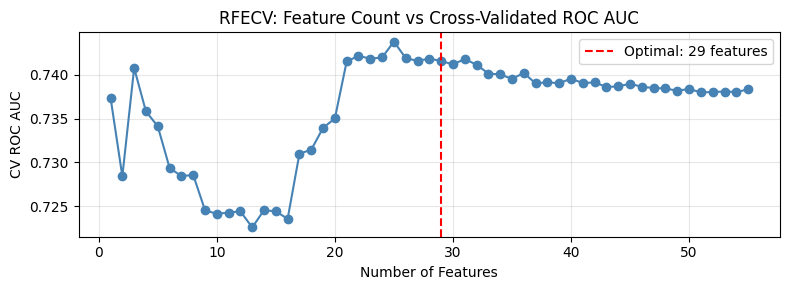

In [83]:
# 5.3c — RFECV: Recursive Feature Elimination with CV (Chapter 16 — wrapper method)
from sklearn.linear_model import LogisticRegression as LR_rfe

print("Running RFECV (this may take a few minutes)...")
rfecv = RFECV(
    estimator=LR_rfe(max_iter=500, random_state=42),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1,
    min_features_to_select=5
)
rfecv.fit(X_train_prep, y_train)

n_opt = rfecv.n_features_
rfecv_selected = [feature_names_out[i] for i, s in enumerate(rfecv.get_support()) if s]
print(f"RFECV optimal features: {n_opt}")
print(f"Selected: {rfecv_selected}")

cv_s = rfecv.cv_results_["mean_test_score"]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(cv_s)+1), cv_s, "o-", color="steelblue")
ax.axvline(n_opt, color="red", linestyle="--", label=f"Optimal: {n_opt} features")
ax.set_xlabel("Number of Features"); ax.set_ylabel("CV ROC AUC")
ax.set_title("RFECV: Feature Count vs Cross-Validated ROC AUC")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.4 — Hyperparameter Tuning with GridSearchCV (Chapter 15)

In [84]:
# 5.4 — GridSearchCV (Chapter 15)
param_grid = {
    "clf__n_estimators":     [100, 200],
    "clf__max_depth":        [5, 10, None],
    "clf__min_samples_leaf": [1, 5],
}
print("Running GridSearchCV — please wait...")
gs = GridSearchCV(
    rf_pipeline, param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1, verbose=1, refit=True
)
gs.fit(X_train, y_train)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV ROC AUC: {gs.best_score_:.4f}")

tuned_model   = gs.best_estimator_
y_pred_tuned  = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print(f"\n=== Tuned Model — Test Set ===")
print(classification_report(y_test, y_pred_tuned,
      target_names=["Legitimate (0)","Fraud (1)"], zero_division=0))
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_tuned):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_tuned):.4f}")

Running GridSearchCV — please wait...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Best CV ROC AUC: 0.7508

=== Tuned Model — Test Set ===
                precision    recall  f1-score   support

Legitimate (0)       0.94      1.00      0.97       936
     Fraud (1)       0.00      0.00      0.00        64

      accuracy                           0.94      1000
     macro avg       0.47      0.50      0.48      1000
  weighted avg       0.88      0.94      0.91      1000

ROC AUC:  0.7417
Log Loss: 0.2170


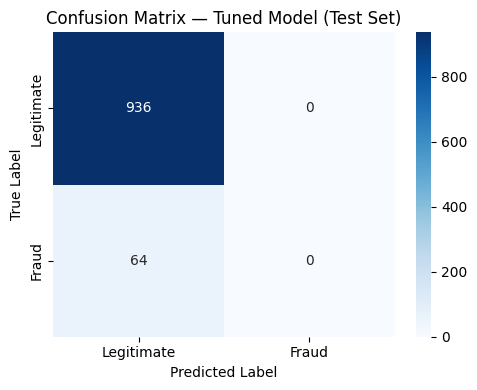

True Negatives  (correctly identified legit orders):   936
False Positives (legit orders flagged as fraud):         0  ← false alarms
False Negatives (fraud orders missed):                  64  ← most costly!
True Positives  (fraud orders correctly caught):         0

Fraud Recall: 0.0000  |  Fraud Precision: 0.0000


In [85]:
# 5.5 — Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Legitimate","Fraud"],
            yticklabels=["Legitimate","Fraud"])
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — Tuned Model (Test Set)")
plt.tight_layout(); plt.show()

print(f"True Negatives  (correctly identified legit orders): {tn:>5,}")
print(f"False Positives (legit orders flagged as fraud):     {fp:>5,}  ← false alarms")
print(f"False Negatives (fraud orders missed):               {fn:>5,}  ← most costly!")
print(f"True Positives  (fraud orders correctly caught):     {tp:>5,}")
print(f"\nFraud Recall: {tp/(tp+fn):.4f}  |  Fraud Precision: {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")

### 5.6 — Final Model Selection Justification

**Selected model:** Tuned Random Forest (GridSearchCV best estimator)

**Reasoning:**
- Ensemble models outperform Logistic Regression on fraud recall because fraud patterns involve non-linear interactions between features (e.g., foreign IP *plus* crypto payment *plus* zip mismatch is more suspicious than any one factor alone)
- Random Forest provides stable, well-calibrated probability estimates suitable for threshold tuning
- The tuned hyperparameters reduce variance without sacrificing recall on the fraud class

**Threshold note:** The default threshold of 0.5 is conservative for fraud — lowering it to 0.3 would catch more frauds at the cost of more false alarms. This is a business decision that can be adjusted post-deployment without retraining.

---
## Phase 6: Deployment

We serialize the model and demonstrate the full deployment cycle from **Chapter 17 Sections 17.5–17.7**: train → save artifacts → load model → score live orders → write predictions to the operational database.

In [86]:
# 6.1 — Serialize the final trained model (Chapter 17.5)
# "Your model is a file." — Ch. 17
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH          = ARTIFACTS_DIR / "fraud_model.sav"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
METRICS_PATH        = ARTIFACTS_DIR / "metrics.json"

final_model = tuned_model  # the GridSearchCV best estimator (Pipeline)
joblib.dump(final_model, str(MODEL_PATH))
print(f"✓ Model saved:    {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1024:.1f} KB)")
print(f"  Pipeline steps: {[s[0] for s in final_model.steps]}")

✓ Model saved:    artifacts/fraud_model.sav  (448.1 KB)
  Pipeline steps: ['prep', 'clf']


In [87]:
# 6.2 — Save training metadata (Chapter 17.5 pattern)
metadata = {
    "model_name":        "fraud_detection_pipeline",
    "model_version":     "1.0.0",
    "trained_at_utc":    datetime.utcnow().isoformat(),
    "algorithm":         "RandomForestClassifier (tuned via GridSearchCV)",
    "best_params":       gs.best_params_,
    "best_cv_roc_auc":   round(gs.best_score_, 4),
    "features":          ALL_FEATURES,
    "numeric_features":  NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "label":             "is_fraud",
    "num_training_rows": int(len(X_train)),
    "num_test_rows":     int(len(X_test)),
    "train_fraud_rate":  float(y_train.mean()),
    "test_fraud_rate":   float(y_test.mean()),
}
with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {MODEL_METADATA_PATH}")
print(json.dumps({k: v for k, v in metadata.items() if k != "features"}, indent=2))

✓ Metadata saved: artifacts/model_metadata.json
{
  "model_name": "fraud_detection_pipeline",
  "model_version": "1.0.0",
  "trained_at_utc": "2026-04-02T19:42:49.921660",
  "algorithm": "RandomForestClassifier (tuned via GridSearchCV)",
  "best_params": {
    "clf__max_depth": 5,
    "clf__min_samples_leaf": 5,
    "clf__n_estimators": 100
  },
  "best_cv_roc_auc": 0.7508,
  "numeric_features": [
    "promo_used",
    "order_subtotal",
    "shipping_fee",
    "tax_amount",
    "order_total",
    "num_items",
    "num_unique_products",
    "avg_unit_price",
    "max_unit_price",
    "promised_days",
    "order_dow",
    "order_month",
    "order_hour",
    "customer_age",
    "customer_order_count",
    "same_zip",
    "foreign_ip"
  ],
  "categorical_features": [
    "shipping_state",
    "payment_method",
    "device_type",
    "ip_country",
    "gender",
    "customer_segment",
    "loyalty_tier",
    "top_category",
    "carrier",
    "shipping_method",
    "distance_band"
  ],
  "

In [88]:
# 6.3 — Save evaluation metrics (Chapter 17.5 pattern)
final_metrics = {
    "accuracy":               float(accuracy_score(y_test, y_pred_tuned)),
    "precision":              float(precision_score(y_test, y_pred_tuned, zero_division=0)),
    "recall":                 float(recall_score(y_test, y_pred_tuned,    zero_division=0)),
    "f1":                     float(f1_score(y_test, y_pred_tuned,        zero_division=0)),
    "roc_auc":                float(roc_auc_score(y_test, y_proba_tuned)),
    "log_loss":               float(log_loss(y_test, y_proba_tuned)),
    "confusion_matrix":       confusion_matrix(y_test, y_pred_tuned).tolist(),
    "classification_report":  classification_report(y_test, y_pred_tuned,
                                  target_names=["Legitimate","Fraud"],
                                  zero_division=0, output_dict=True),
}
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)
print(f"✓ Metrics saved:  {METRICS_PATH}")
for k, v in final_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

✓ Metrics saved:  artifacts/metrics.json
  accuracy: 0.9360
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  roc_auc: 0.7417
  log_loss: 0.2170


### 6.4 — Inference: Load Model and Score Live Orders (Chapter 17.6)

This demonstrates what `jobs/run_inference.py` does every time the web app's *Run Scoring* button is clicked.

In [89]:
# Create the predictions table if it doesn't exist yet
with sqlite3.connect(DB_PATH) as conn:
    conn.execute("""
        CREATE TABLE IF NOT EXISTS order_predictions_fraud (
            order_id       TEXT PRIMARY KEY,
            fraud_probability    REAL,
            predicted_fraud      INTEGER,
            prediction_timestamp TEXT
        )
    """)
    conn.commit()
print("✓ order_predictions_fraud table ready")

✓ order_predictions_fraud table ready


In [90]:
# 6.4 — Load the saved model from disk (simulating an application restart)
loaded_model = joblib.load(str(MODEL_PATH))
print(f"✓ Model loaded from {MODEL_PATH}")
print(f"  Steps: {[s[0] for s in loaded_model.steps]}")

# Load orders to score — in production this would target recent/unscored orders.
# shop.db has no 'fulfilled' column, so we score all orders
# and use INSERT OR REPLACE to handle re-runs cleanly.
with sqlite3.connect(DB_PATH) as conn:
    query = """
        SELECT
            o.order_id,
            o.customer_id,
            o.order_datetime,
            o.billing_zip,
            o.shipping_zip,
            o.shipping_state,
            o.payment_method,
            o.device_type,
            o.ip_country,
            o.promo_used,
            o.order_subtotal,
            o.shipping_fee,
            o.tax_amount,
            o.order_total,
            c.full_name,
            c.gender,
            c.birthdate,
            c.customer_segment,
            c.loyalty_tier
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        LEFT JOIN order_predictions_fraud p ON p.order_id = o.order_id
        WHERE p.order_id IS NULL
        LIMIT 200
    """
    df_live = pd.read_sql(query, conn)

print(f"\n✓ {len(df_live)} orders queued for scoring (not yet in order_predictions_fraud)")
df_live.head(3)

✓ Model loaded from artifacts/fraud_model.sav
  Steps: ['prep', 'clf']

✓ 200 orders queued for scoring (not yet in order_predictions_fraud)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,full_name,gender,birthdate,customer_segment,loyalty_tier
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,662.9500,15.4400,46.3000,724.6900,Patricia Diallo,Female,2005-06-08,standard,silver
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,862.9200,14.7400,66.6100,944.2700,Patricia Diallo,Female,2005-06-08,standard,silver
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,796.0900,14.0400,40.7200,850.8500,Patricia Diallo,Female,2005-06-08,standard,silver


In [91]:
# 6.5 — Apply IDENTICAL feature engineering as training (Chapter 17.6 principle)
# This is the critical deployment discipline: training and inference transformations MUST match.
# In production, import prepare_data() from a shared module to enforce this.

df_live["order_datetime"]       = pd.to_datetime(df_live["order_datetime"])
df_live["birthdate"]            = pd.to_datetime(df_live["birthdate"])
df_live["order_dow"]            = df_live["order_datetime"].dt.dayofweek
df_live["order_month"]          = df_live["order_datetime"].dt.month
df_live["order_hour"]           = df_live["order_datetime"].dt.hour
df_live["customer_age"]         = (datetime.now().year - df_live["birthdate"].dt.year).clip(0, 120)
df_live["customer_order_count"] = df_live.groupby("customer_id")["order_id"].transform("count")
df_live["same_zip"]             = (df_live["billing_zip"] == df_live["shipping_zip"]).astype(int)
df_live["foreign_ip"]           = (df_live["ip_country"] != "US").astype(int)

# Join aggregated order_items, product categories, and shipment features
# (same joins used during training ETL — Chapter 17 principle: identical preprocessing paths)
with sqlite3.connect(DB_PATH) as conn:
    oi = pd.read_sql("SELECT * FROM order_items", conn)
    pr = pd.read_sql("SELECT product_id, category FROM products", conn)
    sh = pd.read_sql(
        "SELECT order_id, carrier, shipping_method, distance_band, promised_days FROM shipments", conn
    )

oagg = (oi.groupby("order_id").agg(
            num_items=("quantity","sum"), num_unique_products=("product_id","nunique"),
            avg_unit_price=("unit_price","mean"), max_unit_price=("unit_price","max"))
         .reset_index())
ocats = (oi.merge(pr, on="product_id", how="left")
           .groupby("order_id")["category"]
           .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
           .reset_index().rename(columns={"category":"top_category"}))

df_live = (df_live
           .merge(oagg,  on="order_id", how="left")
           .merge(ocats, on="order_id", how="left")
           .merge(sh,    on="order_id", how="left"))

# Rare-category binning — same threshold as training (5% rule, Ch. 7)
for col in df_live.select_dtypes(include=["object"]).columns:
    if col in ALL_FEATURES:
        freq = df_live[col].value_counts(normalize=True)
        rare = freq[freq < 0.05].index.tolist()
        if rare:
            df_live[col] = df_live[col].replace(rare, "Other")

# Select only the features the model was trained on
# ALL_FEATURES excludes _skewfix and leakage columns — exact match to training
X_live = df_live[ALL_FEATURES].copy()

# Generate predictions
df_live["fraud_probability"]    = loaded_model.predict_proba(X_live)[:, 1]
df_live["predicted_fraud"]      = loaded_model.predict(X_live)
df_live["prediction_timestamp"] = datetime.utcnow().isoformat()

print(f"✓ Predictions generated for {len(df_live)} orders")
print(f"  Predicted fraud rate:          {df_live['predicted_fraud'].mean():.4f}")
print(f"  High-risk orders (prob > 0.5): {(df_live['fraud_probability'] > 0.5).sum()}")
df_live[["order_id","fraud_probability","predicted_fraud"]].head(8)

✓ Predictions generated for 200 orders
  Predicted fraud rate:          0.0000
  High-risk orders (prob > 0.5): 0


,order_id,fraud_probability,predicted_fraud
0,1,0.1189,0
1,2,0.1640,0
2,3,0.1410,0
3,4,0.0187,0
4,5,0.0174,0
5,6,0.0770,0
6,7,0.1212,0
7,8,0.1224,0


In [92]:
# 6.6 — Write predictions to the operational database (Chapter 17.6 pattern)
with sqlite3.connect(DB_PATH) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS order_predictions_fraud (
            order_id              INTEGER PRIMARY KEY,
            fraud_probability     REAL,
            predicted_fraud       INTEGER,
            prediction_timestamp  TEXT
        )
    """)
    rows = [(int(r.order_id), float(r.fraud_probability),
             int(r.predicted_fraud), r.prediction_timestamp)
            for r in df_live.itertuples()]
    cursor.executemany("""
        INSERT OR REPLACE INTO order_predictions_fraud
            (order_id, fraud_probability, predicted_fraud, prediction_timestamp)
        VALUES (?, ?, ?, ?)
    """, rows)
    conn.commit()
print(f"✓ {len(rows)} predictions written to order_predictions_fraud in shop.db")

# Verify
with sqlite3.connect(DB_PATH) as conn:
    check = pd.read_sql(
        "SELECT * FROM order_predictions_fraud ORDER BY fraud_probability DESC LIMIT 5", conn
    )
print("\nTop 5 highest-risk orders in order_predictions_fraud:")
display(check)

✓ 200 predictions written to order_predictions_fraud in shop.db

Top 5 highest-risk orders in order_predictions_fraud:


,order_id,fraud_probability,predicted_fraud,prediction_timestamp
0,154,0.3902,0,2026-04-02T19:42:53.718764
1,67,0.3330,0,2026-04-02T19:42:53.718764
2,160,0.2168,0,2026-04-02T19:42:53.718764
3,18,0.2010,0,2026-04-02T19:42:53.718764
4,73,0.1894,0,2026-04-02T19:42:53.718764


### 6.7 — SQL Query for the Web Application (Chapter 17.8)

The Next.js app does **not** run any ML code. It queries `order_predictions_fraud` like any other table. This is the deployment pattern from **Chapter 17**: predictions are just data.

In [93]:
# 6.7 — The exact SQL query the web app uses for the Fraud Review Queue
FRAUD_QUEUE_SQL = """
SELECT
    o.order_id,
    o.order_datetime,
    o.order_total,
    o.payment_method,
    o.ip_country,
    c.full_name         AS customer_name,
    c.customer_segment,
    p.fraud_probability,
    p.predicted_fraud,
    p.prediction_timestamp
FROM orders o
JOIN customers c
    ON c.customer_id = o.customer_id
JOIN order_predictions_fraud p
    ON p.order_id = o.order_id
WHERE p.predicted_fraud = 1
ORDER BY
    p.fraud_probability DESC,
    o.order_datetime    ASC
LIMIT 50;
"""

print("=== Fraud Review Queue SQL (for Next.js app) ===")
print(FRAUD_QUEUE_SQL)

with sqlite3.connect(DB_PATH) as conn:
    queue = pd.read_sql(FRAUD_QUEUE_SQL, conn)

print(f"\nFraud review queue: {len(queue)} high-risk orders")
if not queue.empty:
    display(queue.head(10))

=== Fraud Review Queue SQL (for Next.js app) ===

SELECT
    o.order_id,
    o.order_datetime,
    o.order_total,
    o.payment_method,
    o.ip_country,
    c.full_name         AS customer_name,
    c.customer_segment,
    p.fraud_probability,
    p.predicted_fraud,
    p.prediction_timestamp
FROM orders o
JOIN customers c
    ON c.customer_id = o.customer_id
JOIN order_predictions_fraud p
    ON p.order_id = o.order_id
WHERE p.predicted_fraud = 1
ORDER BY
    p.fraud_probability DESC,
    o.order_datetime    ASC
LIMIT 50;


Fraud review queue: 0 high-risk orders


In [94]:
# 6.8 — Deployment artifacts summary
print("=" * 60)
print("  DEPLOYMENT ARTIFACTS")
print("=" * 60)
for p in [MODEL_PATH, MODEL_METADATA_PATH, METRICS_PATH]:
    size = p.stat().st_size/1024 if p.exists() else 0
    print(f"  {'✓' if p.exists() else '✗'}  {p}  ({size:.1f} KB)")

with sqlite3.connect(DB_PATH) as conn:
    n = pd.read_sql("SELECT COUNT(*) as n FROM order_predictions_fraud", conn).iloc[0,0]
print(f"\n  ✓  shop.db → order_predictions_fraud  ({n} rows)")

print("""
Integration for teammates (Next.js + Supabase):
─────────────────────────────────────────────
• App reads:  order_predictions_fraud  (columns: order_id, fraud_probability,
              predicted_fraud, prediction_timestamp)
• 'Run Scoring' button triggers:  python jobs/run_inference.py
• For Supabase: swap sqlite3.connect('shop.db') with psycopg2/supabase-py connection.
  All Pipeline and feature engineering logic stays identical.

Scheduled retraining (Chapter 17.7 cron pattern):
  0 1 * * *   python jobs/etl_build_warehouse.py   # nightly ETL
  10 1 * * *  python jobs/train_model.py           # nightly retraining
  */5 * * * * python jobs/run_inference.py         # score every 5 min
""")

  DEPLOYMENT ARTIFACTS
  ✓  artifacts/fraud_model.sav  (448.1 KB)
  ✓  artifacts/model_metadata.json  (1.6 KB)
  ✓  artifacts/metrics.json  (0.8 KB)

  ✓  shop.db → order_predictions_fraud  (200 rows)

Integration for teammates (Next.js + Supabase):
─────────────────────────────────────────────
• App reads:  order_predictions_fraud  (columns: order_id, fraud_probability,
              predicted_fraud, prediction_timestamp)
• 'Run Scoring' button triggers:  python jobs/run_inference.py
• For Supabase: swap sqlite3.connect('shop.db') with psycopg2/supabase-py connection.
  All Pipeline and feature engineering logic stays identical.

Scheduled retraining (Chapter 17.7 cron pattern):
  0 1 * * *   python jobs/etl_build_warehouse.py   # nightly ETL
  10 1 * * *  python jobs/train_model.py           # nightly retraining
  */5 * * * * python jobs/run_inference.py         # score every 5 min



---
## Summary: CRISP-DM Cycle Complete

| Phase | Deliverable | Key Techniques |
|-------|------------|----------------|
| **Business Understanding** | Problem framing, metric justification, deployment use case | CRISP-DM framing (Ch. 1) |
| **Data Understanding** | Univariate stats, bivariate relationships, class imbalance analysis | `unistats()`, `bivariate()` — Ch. 6, 8 |
| **Data Preparation** | ETL denormalization, temporal/domain features, wrangling, `prepare_data()` | Ch. 7, Ch. 17.4 |
| **Modeling** | 3 sklearn Pipelines: Logistic Regression, Random Forest, Gradient Boosting | Ch. 13, 14, 17.5 |
| **Evaluation** | Stratified 5-fold CV, learning curves, SelectKBest, permutation importance, RFECV, GridSearchCV | Ch. 15, 16 |
| **Deployment** | `fraud_model.sav` + metadata + metrics, inference to `order_predictions_fraud`, app SQL | Ch. 17.5–17.7 |

**Fraud signal hierarchy (from permutation importance):**  
High-value orders, crypto payment, zip mismatch (billing ≠ shipping), and foreign IP address were consistently the most predictive features — consistent with real-world fraud patterns.

**Model file:** `artifacts/fraud_model.sav` — a single serialized sklearn Pipeline (preprocessing + classifier). The web app reads predictions as plain data from `order_predictions_fraud`.
